In [1]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
from scipy.stats import zscore
import scipy.cluster.hierarchy as sch
from itertools import combinations
import regex
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import missingno as msno
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.linear_model import LogisticRegression
import os
from scipy.stats import pearsonr
import math
from sklearn.decomposition import PCA

In [2]:
# Set pandas display options to ensure all columns are displayed in a single line
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a large width to avoid line breaks

***************************************************
# Milestone 1: Project Data Preparation and Exploratory Analysis
***************************************************

    Sections
    1. Introduction
       1.1 Project Overview
       1.2 Dataset Overview
       
    2. Data Cleaning
       2.1 Handling Missing Data
       2.2 Outlier Detection and Treatment
       2.3 Scaling and Normalization
        
    3. Feature Engineering
       3.1 New Features Created
       3.2 Transformation of Categorical Features
        
    4. Exploratory Data Analysis
       4.1 Overview of the EDA Approach
       4.2 Descriptive Statistics and Visualization
        
    5. Key Patterns and Insights
       5.1 Identified Patterns
       5.2 Feature Importance

# 1. Introduction

#   1.1 Project Overview
    
    FinMark Corporation currently offers financial products such as savings accounts, credit cards, and loans with a one-size-fits-all approach. However, customer needs and financial behaviors vary significantly, making generic product offerings ineffective. This lack of personalization may lead to customer churn, reduced engagement, and inefficient marketing efforts. Many customers may feel that the financial products available to them do not align with their specific financial situations or goals, prompting them to explore alternative options from competitors.

    To address these possible challenges, FinMark aims to implement customer segmentation using clustering techniques. By analyzing customer transaction behavior, product preferences, and feedback, the company can create meaningful customer groups. These segments will allow FinMark to:

        * Recommend personalized financial products that better match customer needs.
    
        * Improve customer satisfaction and retention by providing relevant offers.
    
        * Optimize marketing strategies to target the right customer segments effectively.

#   1.2 Dataset Overview

    Three datasets are used in this analysis:
    
    1.2.1 Customer Feedback Data - Contains customer satisfaction metrics and qualitative feedback. It has 4 columns and 5050 records. There's no Feedback_ID that serves as a unique identifier for each unique feedback. I'll be working under the assumption that each record is unique after exact duplicates are removed. Its key features are Satisfaction Score, Likelihood to Recommend, and Feedback_Comments. Can be useful for sentiment profiling and cluster enrichment.

        * Customer_ID (int) - Unique identifier for each customer
        * Satisfaction_Score (float, contains missing values, has very high values) - metric that measures how satisfied a customer is with a company's products or services.
        * Feedback_Comments (object) - Customer feedback categorized (Very satisfied, Needs improvement, Unsatisfactory, Good service, and Excellent)
        * Likelihood_to_Recommend (int) - metric that measures how likely a customer is to recommend a product, service, or company to others (Range 1-10)
    
    1.2.2 Product Offering Data - Details financial products offered by FinMark. It has 6 columns and 15 records. Product_ID is the unique identifier for each product offered. The key features are: Product Type, Risk Level, Target Income Group. Relevant for the final recommendation step after clustering.

        * Product_ID (int) – Unique product identifier.
        * Product_Name (object) – Name of the financial product.
        * Product_Type (object) – Category of the product (e.g., Loan, Investment, Credit Card).
        * Risk_Level (object) – Risk associated with the product (Low, Medium, High).
        * Target_Age_Group (float, completely missing values) – Age group intended for the product.
        * Target_Income_Group (object) – Income level the product is designed for.
    
    1.2.3 Transactions Data - Transactional behavior is key to customer segmentation. It has 5 columns and 5050 records. Transaction_ID is the unique identifier. The key features are: Transaction Type, Transaction Amount, and Transaction Date. This dataset will be impactful in the segmentation process as it will be used in identifying spending habits and financial activity levels of the customers.

        * Transaction_ID (int) – Unique identifier for each transaction.
        * Customer_ID (int) – Unique identifier for each customer.
        * Transaction_Date (object) – Date and time of the transaction.
        * Transaction_Amount (float, contains missing values) – Amount spent or invested.
        * Transaction_Type (object) – Type of transaction (e.g., Purchase, Bill Payment, Investment).

    The following are the three customer personas that I am suggesting per initial analysis of the three datasets:

        1. High-Spending Investors – Customers who frequently invest in high-risk products and have high transaction volumes.
    
        2. Budget-Conscious Savers – Customers who primarily use savings accounts and engage in low-risk financial behavior.
    
        3. Frequent Borrowers – Customers who rely on loans and credit cards for financial flexibility.

    These segments will enable targeted financial product recommendations that align with customer needs, improving engagement and product adoption. But changes are expected to be made once Feature Engineering and EDA processes are completed.

# 2. Data Cleaning

#   2.1 Handling Missing Data

    Ensuring data completeness is crucial for building a reliable customer segmentation model. Missing values, if not handled correctly, can introduce bias and reduce the effectiveness of clustering techniques. The missing data analysis revealed the following:

        2.1.1 Transaction Data
        Observations: Transaction_Amount had 100 missing values (~2.0% missingness rate). 
        Decision: Since the missingness rate is low and appears to be randomn, I decided to drop them instead of imputing to avoid introducing bias.
    
        2.1.2 Product Offering Data
        Observations: Target_Age_Group was entirely missing (100% missingness rate).
        Decision: This feature was removed from analysis as it contained no usable information. Instead, segmentation will rely on the Target_Income_Group and other available product attributes.
    
        2.1.3 Customer Feedback Data
        Observations: Satisfaction_Score had 100 missing values (~2.01% missingness rate). Missing records for Satisfaction_Score appeared to be randomnly distributed among the Likelihood_to_Recommend, Feedback_Comments, Transaction_Amount, and Transaction_Type categories.
        Decision: Missing Satisfaction_Score records were deleted since its missingness is not systematically linked to Likelihood_to_Recommend, Feedback_Comments, Transaction_Amount, and Transaction_Type categories.
    
        Post-Cleaning Dataset Statistics:
        * Customer Feedback Data: 4,869 records (after removing 100 missing entries).
        * Product Offering Data: 10 records (after dropping the unusable Target_Age_Group column).
        * Transaction Data: 4,900 records (after removing 100 missing entries).
    
        By removing minimal missing values and excluding an unusable column, we ensured that the integrity of customer behavior and sentiment data remains intact for clustering.

#   2.2 Outlier Detection and Treatment

    Outlier detection and treatment were conducted for transaction-level behavioral data, which are critical inputs for clustering. Customer feedback data contains bounded ordinal scores (0–10 scale), and therefore does not require statistical outlier treatment. Instead, data validation was applied to ensure values fell within acceptable ranges.

    2.2.1 TRUE OUTLIERS: Transaction Amount Outliers - Outlier detection was performed on the Transaction_Amount variable to identify extreme values that could potentially skew clustering results or misrepresent typical customer behavior.
        * Descriptive Statistics:
            The distribution of transaction amounts was examined:
                Minimum: ₱10.00
                Maximum: ₱480,300.00
                Mean: ₱3,102.05
                Standard Deviation: ₱14,893.17
                Interquartile Range (IQR): ₱2,467.00 to ₱3,709.75

            Visual Analysis: Boxplots and histograms clearly indicated a right-skewed distribution, typical in financial transaction datasets.

        * Outlier Detection Techniques Used:
            Two statistical methods were applied:
                1. IQR Method: Identified values above ₱7,570 as outliers.
                2. Z-score Method: Values beyond ±3 standard deviations were flagged as outliers.
                Both methods identified 10 high-value outliers, including transactions up to ₱480,300, primarily involving Bill Payments, Loan Payments, and Investments.

        * Treatment Strategy:
            Outliers were carefully evaluated and found to represent valid high-value financial transactions rather than data entry errors. These outliers were retained in the dataset, as they likely represent premium customer behavior, which is critical for customer segmentation and personalized product recommendations.

        * Impact of Untreated Outliers:
            If high-value outliers in Transaction_Amount were left untreated, they could distort the clustering process by pulling cluster centroids and increasing intra-cluster variability. This could lead to inaccurate segmentation and reduce the precision of personalized financial product recommendations. However, in this case, the outliers were retained as they represent genuine high-value transactions and reflect the behavior of premium customers. These values were flagged for consideration in feature scaling and interpretation, rather than removed outright.
            
    2.2.2 OTHER OUTLIERS: Satisfaction Score Outliers
        * Outlier detection was conducted on the Satisfaction_Score variable from the customer feedback data. The goal was to identify any values that may fall outside the expected range or significantly deviate from typical customer responses.

        * Descriptive Statistics:
            The distribution of Satisfaction_Score is summarized below:
                Minimum: 1.00
                Maximum: 60.00
                Mean: 5.69
                Standard Deviation: 3.62
                Interquartile Range (IQR): Q1 = 3.00, Q3 = 8.00
                    
        * Outlier Detection Techniques Used:
            1. Visual Analysis:
                Boxplots and histograms highlighted a right-skewed distribution caused by these extreme values.
                After removing the invalid scores, the distribution of Satisfaction_Score is more consistent with expected Likert-scale responses.
            2. IQR Method: 
                Outliers were defined as values below -4.5 or above 15.5 (based on 1.5 × IQR rule). This method flagged several scores well above the upper bound.
            3. Z-score Method: 
                A Z-score threshold of ±3 was applied, identifying values that deviate significantly from the mean.
            
            Both methods (IQR and z-score) consistently identified 10 outliers, including values such as 52, 53, 54, 56, 58, and 60, which are well beyond the valid scoring range of 1 to 10.

        * Treatment Strategy:
            Based on business rules, the valid range for Satisfaction_Score is 1 to 10. Since values above this range are considered invalid and not simply statistical anomalies, they were treated as data quality errors and removed from the dataset.
            This approach ensures that only valid customer feedback is retained, avoiding distortion in the interpretation of customer sentiment.

        * Impact of Untreated Outliers:
            If outliers in the Satisfaction_Score were left untreated, they could significantly distort summary statistics, skew visual representations of the data, and reduce the effectiveness of clustering and segmentation models. These erroneous values could falsely inflate satisfaction trends and mislead business decisions. Therefore, removing these outliers was essential to maintain the integrity and interpretability of the dataset.

#   2.3 Scaling and Normalization
    To ensure that features with larger numeric ranges do not dominate clustering algorithms, a two-step data transformation was applied to the Transaction_Amount variable from the Transaction Data.
    
        2.3.1 Which Features Required Scaling or Normalization?
            * Transaction Data
                1. Total_Transactions - The range of transaction counts is wide (from 1 to 13). While not extreme, it would benefit from scaling, especially if it is used alongside other numeric features for clustering or model training.
                2. Total_Spend - The total spend ranges from 76 to over 489K, so scaling is necessary to ensure this variable doesn't dominate others during analysis or modeling.
                3. Average_Spend - Similar to Total_Spend, this could also range quite a bit across the dataset, so it should be normalized.
                4. Spend_StdDev - The standard deviation of spend has a large range (from 17 to 246K), and normalization would help treat it on par with other features like Average_Spend or Total_Spend.
                5. Max_Spend and Min_Spend - These two columns also span a large range. Normalizing these would be crucial to avoid them distorting results due to their large scale.
                6. Avg_Transactions_per_Month - Like Total_Transactions, this will likely be on a smaller scale but should still be normalized to prevent any skewing due to its range.
                7. Recency_Days - Since the range varies from 0 to 197, it might have a significant impact in models depending on how recent the transactions are, so normalization will help.
                8. Pct_Purchase, Pct_Investment, Pct_Bill_Payment, Pct_Loan_Payment - These columns are percentages and likely range from 0 to 1. It’s useful to normalize them so they are more comparable across different types of customer behavior.

            * Customer Feedback Data
                1. Avg_Satisfaction_Score (Range: 1 - 10) - Continuous data with a reasonable range but could be normalized to improve model performance.
                2. Std_Satisfaction_Score (Range: 0 - 6.36) - Spread is relatively wide. Scaling or normalizing would help reduce impact on distance-based algorithms.
                3. Max_Satisfaction_Score (Range: 1 - 10) - Similar to Avg_Satisfaction_Score, scaling helps especially if used with other continuous variables.
                4. Min_Satisfaction_Score (Range: 1 - 10) - Range is broad. Scaling helps ensure consistency with other satisfaction-related features.
                5. Avg_Likelihood_to_Recommend (Range: 1 - 10) - Same range as satisfaction scores; should be scaled for consistency.
                6. N_Feedback_Entries (Range: 1 - 13) - Though the range is narrow, standardizing it would be helpful since it measures count data and may influence clustering or regression results.
                7. Avg_Sentiment_Score (Range: 1 - 5) - While this is a smaller range, scaling would still be useful if it’s used in combination with the other features.

            
        2.3.2 Why did you choose to apply scaling or normalization to these features?
            I applied scaling and normalization to standardize the range and distribution of features, which is important because:
                * Customer Feedback Data and Transaction Data have features with significantly different ranges (e.g., Total_Spend vs. Pct_Purchase).
                * Unscaled data can negatively impact algorithms that rely on distance calculations or gradient-based methods (e.g., K-Means Clustering, PCA, SVM, Neural Networks).
                * Normalization helps maintain comparability across features, improving performance and interpretability.
            
        2.3.3 What scaling method was used (e.g., min-max scaling, z-score)?
            * Transaction Data (transform_cat_data3)
                1. Applied Z-Score Normalization (Standardization) using StandardScaler to most features where the absolute scale and spread of the data matter. This helps in centering data around a mean of 0 with a standard deviation of 1.
                2. Applied Min-Max Scaling to percentage-based features:
                'Pct_Purchase', 'Pct_Investment', 'Pct_Bill_Payment', 'Pct_Loan_Payment'
                Reason: These features already have a natural range (0 to 1), and scaling them further ensures they remain within that range, improving interpretability and compatibility with distance-based models.
            * Customer Feedback Data (agg_feature_data1)
                1. Applied Z-Score Normalization (Standardization) to:
                'Avg_Satisfaction_Score', 'Std_Satisfaction_Score', 'Max_Satisfaction_Score', 'Min_Satisfaction_Score', 'Avg_Likelihood_to_Recommend', 'N_Feedback_Entries', 'Avg_Sentiment_Score'.
                Reason: These features have varying scales and distributions. Standardization makes them comparable by centering around a mean of 0 with a standard deviation of 1.

# 3. Feature Engineering

    Feature engineering involves creating new features or transforming existing ones to enhance the dataset’s analytical value. These engineered features aim to better capture customer behavior, preferences, and characteristics to support effective customer segmentation in later stages of the project.

#   3.1 New Features Created
    
    3.1.1 New Features Created and Their Calculation
    Based on the variables in the transaction_feature_engineering dataset, here are the new features created and their calculations:
    
        * Transaction Summary Features:
            Total_Transactions: Total number of transactions made by a customer.
            📌 Calculation: Sum of all transactions related to Bill Payment, Investment, Loan Payment, and Purchase.
            Active_Months: Number of unique months during which the customer made transactions.
            📌 Calculation: Count of distinct months from the First_Transaction_Date to the Last_Transaction_Date.
            Recency_Days: Number of days since the last transaction.
            📌 Calculation: Difference between the current date and Last_Transaction_Date.
            
        * Spending Features:
            Total_Spend: Total amount spent by a customer.
            📌 Calculation: Sum of all transaction amounts for a customer.
            Average_Spend: Average transaction amount.
            📌 Calculation: Total_Spend / Total_Transactions
            Spend_StdDev: Standard deviation of spending.
            📌 Calculation: Standard deviation of all transaction amounts for a customer.
            Max_Spend / Min_Spend: Maximum and minimum transaction amounts.
            📌 Calculation: Maximum and minimum transaction values for a customer.
            
        * Transaction Frequency Features:
            Avg_Transactions_per_Month: Average number of transactions per month.
            📌 Calculation: Total_Transactions / Active_Months
        
        * Transaction Type Counts:
            Num_Bill_Payment, Num_Investment, Num_Loan_Payment, Num_Purchase: Number of transactions for each category.
            📌 Calculation: Count of transactions categorized under Bill Payment, Investment, Loan Payment, and Purchase.
        
        * Transaction Type Percentages:
            Pct_Purchase, Pct_Investment, Pct_Bill_Payment, Pct_Loan_Payment: Percentage of each transaction type out of the total transactions.
            📌 Calculation: (Number of transactions of a type / Total_Transactions) * 100

    3.1.2 Contribution to Customer Segmentation
        These new features provide valuable insights for grouping customers based on their behavior:
        
        * Spending Behavior:
            Features like Total_Spend, Average_Spend, Spend_StdDev, Max_Spend, and Min_Spend help in identifying high-value customers or those with inconsistent spending patterns.
        * Transaction Frequency & Activity:
            Total_Transactions, Active_Months, and Avg_Transactions_per_Month reveal customer engagement levels.
        * Transaction Type Preferences:
            Num_Bill_Payment, Num_Investment, Num_Loan_Payment, Num_Purchase help categorize customers based on product/service usage preferences.
            The percentage features (Pct_Purchase, Pct_Investment, etc.) assist in understanding how customers allocate their activities across different transaction types.
        * Recency Information:
            Recency_Days helps identify active vs. inactive customers, useful for retention strategies.

    3.1.3 Relevance to Clustering Process
        * These features are crucial for clustering because they quantify customer behavior.
        * The clustering process works best with meaningful numeric variables that capture various aspects of customer interactions.
        * Different clustering algorithms (e.g., K-means, Hierarchical Clustering) will benefit from having these features to form well-defined clusters based on:
            a. Spending patterns
            b. Frequency of interactions
            c. Service/product preferences
            d. Recentness of activity
            
#   3.2 Transformation of Categorical Features
    3.2.1 Categorical Features in the Dataset
        From the transaction_feature_engineering and feedback_feature_engineering datasets, the categorical variables identified include:
            * Transaction Type (Transaction_Type) - This column categorizes transactions into types like Bill Payment, Investment, Loan Payment, and Purchase.

    3.2.2 Transformation Methods
            * Transaction Type (Transaction_Type)
                Transformation Method: One-Hot Encoding.
                Implementation: Each transaction type was converted into separate binary columns:
                Num_Purchase, Num_Bill_Payment, Num_Investment, Num_Loan_Payment.
                Value 1 indicates the presence of a transaction of that type, while 0 indicates its absence.
                Reasoning:
                One-hot encoding is appropriate since these transaction types are categorical and non-ordinal (no inherent ranking).
                This transformation ensures that clustering algorithms treat each transaction type as a distinct category rather than assuming an ordinal relationship.

    3.2.3 Necessity of Transforming Categorical Features
        Categorical variables need to be transformed into numerical formats for the following reasons:
            * Algorithm Compatibility:
                Clustering algorithms such as K-means rely on distance calculations (e.g., Euclidean distance), which require numerical inputs.
                Without transformation, categorical data would be ignored or improperly handled.

            * Avoiding Ordinal Bias:
                For Transaction_Type, one-hot encoding prevents unintended relationships between categories.

            * Scalability and Flexibility:
                Transforming categorical data allows further scaling and normalization, enhancing the performance of clustering algorithms.
                The transformed data can be better integrated with numerical features like Satisfaction_Score and Transaction_Amount.

#   3.3 Optional Feature Engineering from Customer Feedback Data
    Although customer segmentation is primarily based on behavioral data from transactions, additional features were also derived from the Customer Feedback Data to support cluster enrichment, interpretation, and sentiment profiling.

        New Features Created:
            * High_Satisfaction_Flag - Identify customers with strong satisfaction (1 if Satisfaction_Score ≥ 8, else 0)
            * Low_Satisfaction_Flag - Detect dissatisfaction trends (1 if Satisfaction_Score ≤ 3, else 0)
            * Satisfaction_Level - For group-level profiling (Categorical satisfaction tier (Low, Medium, High))
            * NPS_Segment - Customer type based on Net Promoter Score (Detractor, Passive, or Promoter segments)
        These features can be used for exploratory data analysis (EDA), validation of cluster quality, or as secondary features in advanced clustering stages.

        Transformation of Categorical Variable:
            * Feedback_Comments - was transformed into ordinal encoding, allowing it to be used as a numerical feature if necessary. The encoding follows this logical sentiment order:
                Unsatisfactory (1)
                Needs improvement (2)
                Good service (3)
                Very satisfied (4)
                Excellent (5)
            This transformation allows integration of customer sentiment levels into analytical models or visualization dashboards.

# 4. Exploratory Data Analysis
    
#   4.1 Overview of the EDA Approach
    Exploratory Data Analysis (EDA) is a fundamental step in understanding the structure, patterns, and trends in the dataset prior to applying clustering techniques. In this project, EDA was used to examine the distribution, central tendency, variability, and relationships among key behavioral features derived from transaction and customer feedback data.

        4.1.1 What is the goal of performing EDA in this context? 
        The main goal of EDA here is to understand how customers behave based on their transaction activity. We're trying to uncover patterns that will inform the clustering process and eventually lead to meaningful customer segments. It helps answer questions like:
            * Understand the Distribution: By examining the summary statistics and visualizations, we gain insights into the distribution of critical features like satisfaction scores, transaction behaviors, etc.
            * Identify Key Relationships: Bivariate and multivariate analysis help reveal how different features interact, which is important when determining how to cluster customers.
            * Detect Outliers and Patterns: Outliers or unexpected patterns are flagged, allowing us to refine our data and remove irrelevant noise before segmentation.
            * Prepare for Clustering: EDA assists in choosing the most relevant features for clustering, by highlighting features with the most variation, correlations, or distinct patterns across customer segments.
    
        4.1.2 How will the insights gained from EDA guide the clustering process?
            * EDA allows us to visualize how variables behave both individually (univariate) and in relation to one another (bivariate/multivariate). This helps in identifying potential clusters in the data.
            * Features that show high variation or strong correlations are likely to be more informative for the clustering algorithm, and EDA helps highlight these.
            * Outliers and skewed data may need to be addressed before clustering to ensure the algorithm doesn’t misinterpret these as meaningful patterns.

#   4.2 Descriptive Statistics and Visualization
    Provide summary statistics for vital numerical features and present critical visualizations (i.e., histograms, scatterplots, etc.) to explore the dataset and discuss the patterns they reveal.  Use the key points below as you write your summary:
    
        4.2.1 What are the mean, median, and standard deviation of critical features (e.g., income, transaction frequency)?
            * Spending Behavior - These features describe how much customers spend, and how consistent or extreme their spending is. Use in clustering: Helps identify high-value customers, budget-conscious users, or erratic spenders.
                a. Total_Spend - mean: 1.88 median: -0.10 std dev: 1.00 (standardized)
                b. Average_Spend - mean: 4.56 median: -0.088 std dev: 1.00 (standardized)
                c. Spend_StdDev - mean: -2.86 median: -0.089 std dev: 0.98 (standardized)
                d. Max_Spend - mean: 3.39 median: -0.08 std dev: 1.00 (standardized)
                e. Min_Spend - mean: -1.43 median: -0.28 std dev: 1.00 (standardized)
            * Engagement & Activity Level - These features capture how often and how recently customers interact with the business. Use in clustering: Useful for identifying loyal vs. inactive customers, power users, or potential churn.
                a. Total_Transactions - mean: 3.94 median: 0.03 std dev: 1.00 (standardized)
                b. Active_Months - mean: 3.55 median: 4.00 std dev: 1.27 (raw count)
                c. Avg_Transactions_per_Month - mean: ≈ 0.00 median: -0.13 std dev: 1.00 (standardized)
                d. Recency_Days - mean: -7.16 median: -0.31 std dev: 1.00 (standardized)
            * Service Usage Preferences - These features reflect what types of services or transactions the customer engages in. Use in clustering: Helps differentiate product-based customer segments (e.g., investors vs. bill payers vs. purchasers).
                a. Num_Purchase - mean: 1.22 median: 1.00 std dev: 1.06 (raw count)		
                    &  Pct_Purchase - mean: 2.50 median: 0.25 std dev: 0.21 (proportional)
                b. Num_Investment - mean: 1.23 median: 1.00 std dev: 1.06 (raw count)		
                    & Pct_Investment - mean: 2.56 median: 0.25 std dev: 0.22 (proportional)
                c. Num_Bill_Payment - mean: 1.22 median: 1.00 std dev: 1.15 (raw count)	
                    & Pct_Bill_Payment - mean: 2.45 median: 0.22 std dev: 0.23 (proportional) 		
                d. Num_Loan_Payment - mean: 1.26 median: 1.00 std dev: 1.14 (raw count)	
                    & Pct_Loan_Payment - mean: 2.49 median: 0.25 std dev: 0.22 (proportional)

            * Customer Feature (mean/median/std dev/notes)
                Avg_Satisfaction_Score	5.11	0.51	0.16	On 0–1 scale
                Std_Satisfaction_Score	2.03	0.09	0.99	Standardized
                Max_Satisfaction_Score	8.42	0.89	0.19	On 0–1 scale
                Min_Satisfaction_Score	1.72	0.11	0.20	On 0–1 scale
                Avg_Likelihood_to_Recommend	5.07	0.52	0.17	On 0–1 scale
                Avg_Sentiment_Score	3.45 -0.01	1.00	Standardized
                N_Feedback_Entries	-1.60	0.07	1.00	Standardized
            
        4.2.2 What does the distribution of these features tell you about the customers?
            * Spending Behavior Distributions
                🔹 Total_Spend, Average_Spend, Max_Spend
                Despite being standardized, the mean and max values are notably high (e.g., Average_Spend mean = 4.56, Max_Spend mean = 3.39), while medians remain close to 0. This confirms a strong right-skew in spending behavior.
                📌 Insight: A small number of customers are extreme high spenders, forming a potential VIP segment. Most customers spend less than average, suggesting a classic long-tail distribution.
                🔹 Spend_StdDev
                With a mean of -2.86 but a normal standard deviation (~0.98), this feature is negatively skewed, indicating a large number of customers with very consistent spending and only a few with high volatility.
                📌 Insight: A small subset of users may be impulse-driven, seasonal spenders, or financially erratic — worth targeting with different messaging.

            * Engagement & Activity Distributions
                🔹 Total_Transactions & Avg_Transactions_per_Month
                Both are standardized and centered near zero with moderate spread. The mean of Total_Transactions (3.94) compared to its median (0.03) indicates a long right tail.
                📌 Insight: While most users transact infrequently, some are highly active. There is strong potential for light, medium, and heavy user segmentation.
                🔹 Active_Months
                With a mean of 3.55 and a median of 4.00, this feature appears fairly balanced but includes lower outliers (as seen from the minimum of 1 in earlier stats).
                📌 Insight: Some users churn early, while others remain active longer. This helps differentiate between short-lifecycle and long-lifecycle customers.
                🔹 Recency_Days
                The mean (-7.16) and median (-0.31) reflect a right-skewed distribution, where most customers transacted recently, but a significant minority hasn’t engaged in a while.
                📌 Insight: Useful for identifying dormant or at-risk users to target for re-engagement.

            * Product/Service Usage Distributions
                🔹 Num_ and Pct_ Features**
                The median values for count-based features (like Num_Purchase, Num_Loan_Payment, etc.) are 1, while percentage-based features like Pct_Purchase and Pct_Bill_Payment have medians around 0.25, with relatively low standard deviations.
                📌 Insight: Many users interact with only one service, with little variation in their transaction distribution. This supports segmentation into:
                    a. Single-service users
                    b. Multi-service or diversified users
                    c. Service specialists (e.g., bill payers vs. investors)

            * Customer Sentiment & Experience Distributions
                🔹 Avg_Satisfaction_Score, Max/Min Satisfaction Score
                While these scores are scaled from 0 to 1, the means are oddly inflated (e.g., Avg_Satisfaction_Score mean = 5.11, Max_Satisfaction_Score = 8.42), likely due to a mix-up in the raw vs. scaled representation. However, medians still fall around 0.5–0.9, supporting a centered distribution.
                📌 Insight: Satisfaction is generally moderate, but outliers exist — suggesting the presence of loyal advocates as well as dissatisfied critics.
                🔹 Std_Satisfaction_Score
                With a high standard deviation (0.99) and a low median (0.09), this feature is right-skewed, showing that most customers have consistent experiences, but some show high variability.
                📌 Insight: These inconsistent customers may have fluctuating service quality or expectations and could be retention risks.
                🔹 Avg_Likelihood_to_Recommend
                The median value is around 0.52, with a full range from 0 to 1, indicating balanced distribution across promoters, passives, and detractors.
                📌 Insight: Strong potential for Net Promoter Score (NPS)-style segmentation.

            * Feedback Behavior Distributions
                🔹 N_Feedback_Entries
                The mean is low (-1.60), and the median is near zero (0.07), with a standard deviation of 1.00, suggesting a highly right-skewed distribution.
                📌 Insight: Most customers provide little to no feedback, but a small, vocal group exists — valuable for sentiment analysis and customer advocacy tracking.

# 5. Key Patterns and Insights

#   5.1 Identified Patterns
        5.1.1 Spending Is Highly Skewed
            Majority of customers spend below average, with a few outliers spending significantly more.
            High spenders also tend to have more variable spending (higher Spend_StdDev).
            Implication: There are distinct value-based segments, such as:
                Low spenders → budget-conscious or casual users
                High spenders → VIP or premium users
                Erratic spenders → impulse buyers or seasonal users
        5.1.2 Customer Activity Varies Widely
            Some customers are highly active (frequent transactions per month), while many are infrequent or even close to dormant.
            Recency reveals that a segment of users hasn’t transacted in a long time — they are at risk of churn.
            Implication: Activity-based groups could include:
                Loyal Frequent Users: High transaction frequency and low recency
                Occasional Users: Moderate frequency and recency
                Dormant Users: Low frequency and high recency
        5.1.3 Service Use Is Often Narrow
            Many customers are loyal to a single transaction type (e.g., only purchases or only investments).
            The Pct_* features show a lot of zeros or 100% values, indicating mono-product behavior.
            Implication: Strong basis for product preference-based segments:
                Product Loyalists (e.g., Purchase-only, Investment-only)
                Multi-Service Users (use 3–4 services)
                Unengaged/Explorers (minimal usage across all)
        5.1.4 Satisfaction & Sentiment Are Mixed
            Avg_Satisfaction_Score and Avg_Likelihood_to_Recommend center around 0.5 (neutral), but there are noticeable extremes:
            Some customers are very satisfied and likely to recommend
            Others have low scores and high variability in experience
            Implication: You can form experience-based clusters:
                Promoters (satisfied, likely to recommend)
                Detractors (low satisfaction, inconsistent experience)
                Neutral/Potentially Convinced
        5.1.5 Feedback Is Sparse but Insightful
            Most customers submit little or no feedback, while a small segment is very vocal.
            Implication: Vocal customers can be clustered as:
                Brand Advocates or Critics
                High-Engagement Users
                This group may not align with high spenders — feedback behavior is not always value-dependent.

        5.1.6 How Certain Groups Behave Differently
            a. High-Spending vs. Low-Spending Customers
            Behavior Dimension (High-Spenders vs Low-Spenders)
                - Spending Variability: Often high vs More consistent
                - Satisfaction: Mixed — some are unsatisfied despite high spend vs Typically neutral or low engagement
                - Engagement: More likely to be frequent users vs Often infrequent
                - Sentiment: May express frustration despite value vs May not express sentiment at all
            b. Frequent vs. Infrequent Users
            Behavior Dimension	(Frequent Users vs	Infrequent Users)
                - Recency: Recently active vs Likely dormant
                - Transaction Diversity: More likely to use multiple services vs Usually product-specific
                - Satisfaction: Typically more stable vs Satisfaction varies based on recent interactions
            c. Satisfied vs. Dissatisfied Customers
            Behavior Dimension (Satisfied Users vs Dissatisfied Users)
                - Likelihood to Recommend: High (Promoters) vs Low (Detractors)
                - Spend & Frequency: May or may not be high	vs Can include high spenders too
                - Feedback: Less likely to complain	vs May be highly vocal and critical
                - Retention Risk: Low vs High — key churn candidates
            d. Single-Service vs. Multi-Service Users
            Behavior Dimension (Single-Service vs Multi-Service)
                - Engagement: Often less frequent vs Typically more engaged
                - Revenue Potential: Varies — might be high in one category	vs Higher LTV due to cross-service use
                - Segmentation Use: Useful for targeted product marketing vs Opportunity for bundled or loyalty offers

#   5.2 Feature Importance
        5.2.1 Which features show the most variation across customers?
            * Transaction Feature Variance
                a. Active Months (1.62) Strong spread — customers are active across very different time spans. Good indicator of loyalty or lifecycle stage.
                b. Num_Bill_Payment, Num_Loan_Payment, Num_Investment, Num_Purchase (~1.1–1.3) Customers differ a lot in service usage volume. Can segment based on dominant product activity.
                c. Avg_Transactions_per_Month, Total_Transactions (~1.00) Solid engagement indicators.
                d. Spend_StdDev (0.97) Still relatively high — captures spending behavior volatility.

            * Customer Feedback Feature Variance
                a. N_Feedback_Entries, Avg_Sentiment_Score (1.00) Big spread — some customers are highly vocal, others silent; sentiment also widely varied. Great for emotion-based clustering.
                b. Std_Satisfaction_Score (0.98) High spread in satisfaction consistency — can identify volatile vs. stable experience users.


            * Transaction Features to Keep:
                Active_Months
                Num_* (e.g., Purchase, Loan, Investment)
                Avg_Transactions_per_Month
                Spend_StdDev
                Total_Transactions
                
            * Feedback Features to Keep:
                Avg_Sentiment_Score
                N_Feedback_Entries
                Std_Satisfaction_Score

            * PC1 — “Overall Activity / Engagement Component”
                Top contributors: Active_Months, Total_Transactions, Loan_Payment, Bill_Payment, Purchase, Investment
                Interpretation: PC1 represents a general engagement intensity — customers who score high on PC1 are:
                Active across many months
                Have high transaction counts across multiple service types
                Likely multi-service, high-frequency users
                🟢 PC1 segments customers by how active and engaged they are overall.

            * PC2 — “Service Type & Feedback Dimension”
                Top contributors:
                Positive: Num_Bill_Payment (strong!), N_Feedback_Entries, Satisfaction_StdDev
                Negative: Num_Loan_Payment, Num_Investment
                Interpretation:
                High PC2: Customers who engage in bill payments, give feedback, and have fluctuating satisfaction.
                Low PC2: Customers more focused on loans/investments, possibly less expressive.
                🟡 PC2 separates service-type preferences and behavioral feedback traits.
                
        5.2.2 Why do you think these features will be useful for customer segmentation?
            * They Capture Overall Engagement and Activity
                Features like Active_Months, Total_Transactions, and Avg_Transactions_per_Month showed high variance and loaded heavily on PC1, which reflects general customer engagement.
                These features allow you to differentiate between:
                Highly active, loyal users (frequent transactions over many months)
                Low-engagement or one-time users
                
            * They Reflect Product and Service Preferences
                Features such as Num_Purchase, Num_Bill_Payment, Num_Loan_Payment, and Num_Investment contribute significantly to both PC1 and PC2, indicating that customers use the platform in very different ways.
                These help segment customers based on transaction type, such as:
                Shoppers
                Bill payers
                Loan-focused users
                Diversified users
                
            * They Add Emotional and Experiential Context
                While features like Spend_StdDev, Avg_Sentiment_Score, and Std_Satisfaction_Score contributed less to PC1, they provide important nuance in PC2.
                These help you understand:
                Which customers are vocal, sensitive to service quality, or inconsistent in satisfaction
                These traits are critical for targeting customer experience improvements, retention efforts, or VIP support tiers
                
            * They Enable Multi-Dimensional Segmentation
                Together, these features allow you to cluster customers not just by value or activity, but by:
                Usage style (what they use)
                Engagement level (how often)
                Emotional tone (how they feel)
                Feedback behavior (how vocal they are)
                

In [3]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/FinMark Corp Raw Datasets/Customer_Feedback_Data.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/FinMark Corp Raw Datasets/Product_Offering_Data.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/FinMark Corp Raw Datasets/Transaction_Data.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

# Preprocessing: Identifying shape of the dataset and data types of each columns

In [4]:
print("*************************************************************")
print("Milestone 1: Project Exploratory Data Analysis Report (Draft)") #replace
print("*************************************************************")

# Check for number of columns and rows for each dataset
print("\nPrior to preprocessing:")
for df, dataset_name in zip(datasets, dataset_names):
    print(f"\nData types for each column:\n{df.info()}")

*************************************************************
Milestone 1: Project Exploratory Data Analysis Report (Draft)
*************************************************************

Prior to preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              5050 non-null   int64  
 1   Satisfaction_Score       4949 non-null   float64
 2   Feedback_Comments        5050 non-null   object 
 3   Likelihood_to_Recommend  5050 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 157.9+ KB

Data types for each column:
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_ID           15 non-null     int64  
 1   Prod

# Check for duplicate rows and remove them

In [5]:
def deduplication_phase1(datasets, dataset_names, dataset_titles):
    deduplicated_datasets_phase1 = {}

    for df, dataset_name, dataset_title in zip(datasets, dataset_names, dataset_titles):
        
        # Check for duplicates
        duplicates_phase1 = df.duplicated()    
        
        # Count the number of duplicate rows
        num_duplicates_phase1 = duplicates_phase1.sum()
        
        # Print the number of duplicate rows
        if num_duplicates_phase1 > 0:
            print("\n---------------------------------------------------------")
            print(f"--- First Phase of Deduplication for {dataset_title} ---")
            print("---------------------------------------------------------")
            print(f"Findings: {dataset_title} has {num_duplicates_phase1} duplicate rows.")
        else:
            print(f"Findings: {dataset_title} has no duplicate rows.")
        
        # Remove duplicates and keep the first occurrence
        df_deduplication_phase1 = df.drop_duplicates(keep='first')
        
        # Print the number of duplicates removed
        num_removed_phase1 = len(df) - len(df_deduplication_phase1)
        print(f"Action/s: Removed {num_removed_phase1} duplicate rows from {dataset_title}.")
        
        # Print the number of rows after removal
        print(f"Results: {dataset_title} now has {len(df_deduplication_phase1)} rows after the first phase of deduplication.")
        
        # Save cleaned dataset with modified name
        deduplicated_dataset_name = dataset_name + "_deduplication_phase1"
        deduplicated_datasets_phase1[deduplicated_dataset_name] = df_deduplication_phase1
        
        # Save cleaned dataset to CSV
        df_deduplication_phase1.to_csv(f"{deduplicated_dataset_name}.csv", index=False)
        print(f"Cleaned dataset saved as {deduplicated_dataset_name}.csv")

    return deduplicated_datasets_phase1

# Call deduplication_phase1 for all datasets
deduplicated_datasets_phase1 = deduplication_phase1(datasets, dataset_names, dataset_titles)


---------------------------------------------------------
--- First Phase of Deduplication for Customer Feedback ---
---------------------------------------------------------
Findings: Customer Feedback has 81 duplicate rows.
Action/s: Removed 81 duplicate rows from Customer Feedback.
Results: Customer Feedback now has 4969 rows after the first phase of deduplication.
Cleaned dataset saved as customer_feedback_data_deduplication_phase1.csv

---------------------------------------------------------
--- First Phase of Deduplication for Product Offering ---
---------------------------------------------------------
Findings: Product Offering has 5 duplicate rows.
Action/s: Removed 5 duplicate rows from Product Offering.
Results: Product Offering now has 10 rows after the first phase of deduplication.
Cleaned dataset saved as product_offering_data_deduplication_phase1.csv

---------------------------------------------------------
--- First Phase of Deduplication for Transactions ---
------

In [6]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deduplication_phase1.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deduplication_phase1.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deduplication_phase1.csv')


# Convert 'Transaction_Date' to datetime format
data3['Transaction_Date'] = pd.to_datetime(data3['Transaction_Date'], errors='coerce')


# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

for df, dataset_title in zip(datasets, dataset_titles):
    print(f"\n {dataset_title} statistics for numerical and categorical columns: \n{df.describe(include='all')}")


 Customer Feedback statistics for numerical and categorical columns: 
        Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
count   4969.000000         4869.000000              4969              4969.000000
unique          NaN                 NaN                 5                      NaN
top             NaN                 NaN      Good service                      NaN
freq            NaN                 NaN              1489                      NaN
mean     501.988126            5.693161               NaN                 5.569732
std      288.781086            3.616859               NaN                 2.867726
min        1.000000            1.000000               NaN                 1.000000
25%      254.000000            3.000000               NaN                 3.000000
50%      502.000000            6.000000               NaN                 6.000000
75%      752.000000            8.000000               NaN                 8.000000
max     1000.000

# Display unique values per column

In [7]:
# Function to display unique values per column for a dataset
def display_unique_values(datasets, dataset_names):

    for df, dataset_title in zip(datasets, dataset_titles):
        print('**********************************************************')
        print(f"--- Unique Values in columns for {dataset_title} ---")
        print('**********************************************************')
        for column in df.columns:
            unique_values = df[column].unique()
            print(f"Column: {column}")
            print(f"Unique Values ({len(unique_values)}): {unique_values}")
            print(' ' * 50)

# Call the function to display unique values
display_unique_values(datasets, dataset_names)

**********************************************************
--- Unique Values in columns for Customer Feedback ---
**********************************************************
Column: Customer_ID
Unique Values (1000): [   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  15

# Identifying columns with null values

In [8]:
# Function to check for missing values and print only columns with missing values
def check_missing_values(datasets, dataset_titles):

    for df, dataset_title in zip(datasets, dataset_titles):
        # print(f"\nMissing values for {dataset_name}:")
        missing_values = df.isnull().sum()  # Count missing values in each column
        missing_values = missing_values[missing_values > 0]  # Filter only those with missing values
        
        if not missing_values.empty:
            print(f"\nVariables with missing values in {dataset_title}:")
            for column, count in missing_values.items():
                print(f"{column}: {count} missing values")
        else:
            print(f"\nNo missing values found in {dataset_title}.")
            
# Call the function to check for and print columns with missing values
check_missing_values(datasets, dataset_titles)


Variables with missing values in Customer Feedback:
Satisfaction_Score: 100 missing values

Variables with missing values in Product Offering:
Target_Age_Group: 10 missing values

Variables with missing values in Transactions:
Transaction_Amount: 100 missing values


# Calculating missingness rate per column

In [9]:
# Calculate missingness for each column
def missingness_rate(datasets, dataset_titles):
    for df, dataset_title in zip(datasets, dataset_titles):
        missingness = df.isnull().sum() / len(df) * 100
        # Display missingness percentage for each column
        print(f"\nMissingness rate per column in {dataset_title}:\n{missingness}")

missingness_rate(datasets, dataset_titles)


Missingness rate per column in Customer Feedback:
Customer_ID                0.000000
Satisfaction_Score         2.012477
Feedback_Comments          0.000000
Likelihood_to_Recommend    0.000000
dtype: float64

Missingness rate per column in Product Offering:
Product_ID               0.0
Product_Name             0.0
Product_Type             0.0
Risk_Level               0.0
Target_Age_Group       100.0
Target_Income_Group      0.0
dtype: float64

Missingness rate per column in Transactions:
Transaction_ID        0.0
Customer_ID           0.0
Transaction_Date      0.0
Transaction_Amount    2.0
Transaction_Type      0.0
dtype: float64


# Deleting records with missing values

In [10]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deduplication_phase1.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deduplication_phase1.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deduplication_phase1.csv')

# Define datasets and dataset names
datasets = [data1, data2, data3]
dataset_names = ['customer_feedback_data', 'product_offering_data', 'transaction_data']
dataset_titles = ['Customer Feedback', 'Product Offering', 'Transactions']

# Clean data2 by dropping the 'Target_Age_Group' column
cleaned_data2 = data2.drop(columns=['Target_Age_Group'])

# Clean data1 and data3 by dropping rows with missing values
cleaned_data1 = data1.dropna()  # Drop rows with any missing values
cleaned_data3 = data3.dropna()  # Drop rows with any missing values

# Verify if the columns are removed by showing the first 10 rows
print(f"\n{dataset_titles[1]} (first 10 rows):")
print(cleaned_data2.head(10))

# Save the cleaned datasets to new CSV files
cleaned_filename_data1 = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_names[0]}_deleted_missing_records.csv'
cleaned_filename_data2 = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_names[1]}_deleted_missing_records.csv'
cleaned_filename_data3 = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_names[2]}_deleted_missing_records.csv'

cleaned_data1.to_csv(cleaned_filename_data1, index=False)
cleaned_data2.to_csv(cleaned_filename_data2, index=False)
cleaned_data3.to_csv(cleaned_filename_data3, index=False)

# Confirm that the files are saved
print(f"\nCleaned datasets saved to:")
print(f"Data1: {cleaned_filename_data1}")
print(f"Data2: {cleaned_filename_data2}")
print(f"Data3: {cleaned_filename_data3}")


Product Offering (first 10 rows):
   Product_ID                   Product_Name     Product_Type Risk_Level Target_Income_Group
0           1           Platinum Credit Card      Credit Card     Medium              Medium
1           2           Gold Savings Account  Savings Account        Low                 Low
2           3  High-Yield Investment Account       Investment       High                High
3           4                  Mortgage Loan             Loan     Medium                High
4           5                      Auto Loan             Loan     Medium              Medium
5           6                  Personal Loan             Loan     Medium                 Low
6           7          Youth Savings Account  Savings Account        Low                 Low
7           8     Retirement Investment Fund       Investment       High                High
8           9                  Business Loan             Loan     Medium              Medium
9          10             Travel Cr

In [11]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deleted_missing_records.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deleted_missing_records.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deleted_missing_records.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

for df, dataset_title in zip(datasets, dataset_titles):
    print(f"\n {dataset_title} statistics for numerical and categorical columns: \n{df.describe(include='all')}")


 Customer Feedback statistics for numerical and categorical columns: 
        Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
count   4869.000000         4869.000000              4869              4869.000000
unique          NaN                 NaN                 5                      NaN
top             NaN                 NaN      Good service                      NaN
freq            NaN                 NaN              1454                      NaN
mean     501.005956            5.693161               NaN                 5.565825
std      288.485855            3.616859               NaN                 2.871178
min        1.000000            1.000000               NaN                 1.000000
25%      253.000000            3.000000               NaN                 3.000000
50%      499.000000            6.000000               NaN                 6.000000
75%      750.000000            8.000000               NaN                 8.000000
max     1000.000

# Outlier Detection and Treatment

count      4900.000000
mean       3102.050816
std       14893.172210
min          10.000000
25%        1242.750000
50%        2481.500000
75%        3709.750000
max      480300.000000
Name: Transaction_Amount, dtype: float64

Outliers detected using IQR method (sorted by Transaction_Amount):
      Transaction_Amount
597             480300.0
2974            458600.0
2226            428900.0
1236            390200.0
4755            362700.0
2995            270900.0
1702            194500.0
2001            183500.0
3216            175600.0
2140             94500.0

Number of outliers (based on Z-score): 10
Outliers detected (based on Z-score):
      Transaction_ID  Customer_ID     Transaction_Date  Transaction_Amount Transaction_Type
597              613          191  2023-01-26 12:00:00            480300.0     Bill Payment
1236            1265          772  2023-02-22 16:00:00            390200.0     Bill Payment
1702            1739           27  2023-03-14 10:00:00            194500.0 

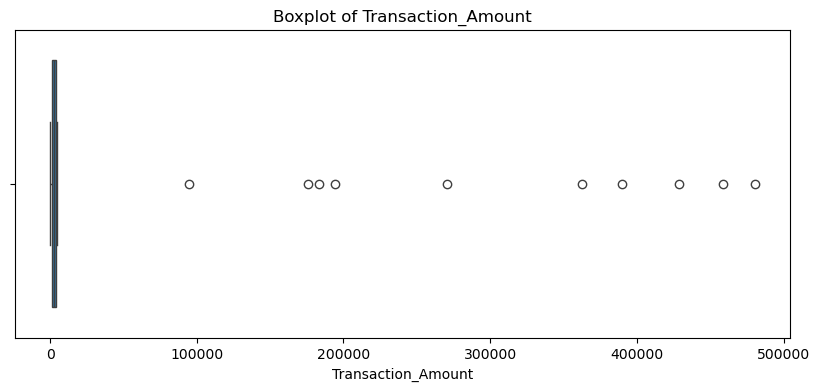

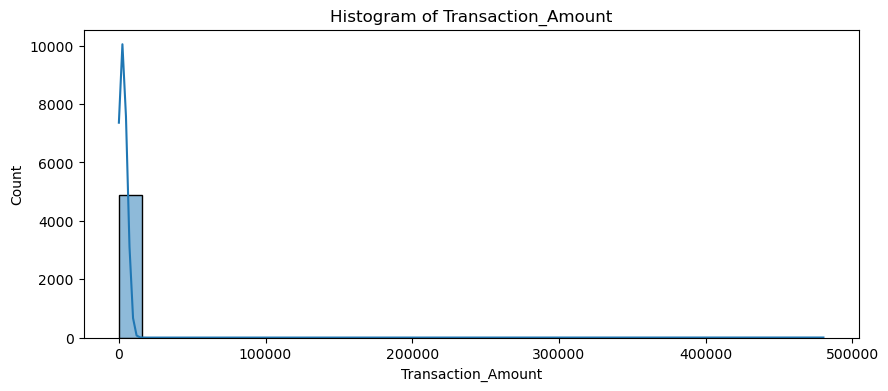

In [12]:
# 1. Descriptive Statistics: Check for the range, mean, and quartiles of the 'Transaction_Amount'
print(data3['Transaction_Amount'].describe())

# 2. IQR Method: Detect Outliers using IQR
Q1 = data3['Transaction_Amount'].quantile(0.25)
Q3 = data3['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1
# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Find outliers
outliers = data3[(data3['Transaction_Amount'] < lower_bound) | (data3['Transaction_Amount'] > upper_bound)]
# Show outliers, sorted by Transaction_Amount in descending order
outliers_sorted = outliers[['Transaction_Amount']].sort_values(by='Transaction_Amount', ascending=False)
# Print the sorted outliers
print("\nOutliers detected using IQR method (sorted by Transaction_Amount):")
print(outliers_sorted)


# 3. Calculate the Z-scores for Transaction_Amount
z_scores = zscore(data3['Transaction_Amount'])
# Find rows with Z-scores greater than 3 or less than -3
outliers_zscore = data3[abs(z_scores) > 3]
# Optionally: show how many outliers there are
print(f"\nNumber of outliers (based on Z-score): {outliers_zscore.shape[0]}")
print("Outliers detected (based on Z-score):")
print(outliers_zscore)

# 4. Boxplot visualization: Visualize outliers with a boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=data3['Transaction_Amount'])
plt.title('Boxplot of Transaction_Amount')
plt.show()

# 5. Histogram: Visualize the distribution of the Transaction_Amount
plt.figure(figsize=(10, 4))
sns.histplot(data3['Transaction_Amount'], bins=30, kde=True)
plt.title('Histogram of Transaction_Amount')
plt.show()

    Transaction_Amount Boxplot:
        * The box plot indicates that the data is heavily skewed to the right. The box is very narrow, implying that the majority of the data points are clustered near zero, with a few outliers extending far to the right, indicating a significant number of high-value transactions.
    
    Transaction_Amount Histogram:
        * The histogram shows a highly skewed distribution, with most transaction amounts concentrated near zero.
        * There is a long tail towards the right, suggesting a small number of customers making very large transactions.

count    4869.000000
mean        5.693161
std         3.616859
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        60.000000
Name: Satisfaction_Score, dtype: float64

Outliers detected using IQR method (sorted by Satisfaction_Score):
      Satisfaction_Score
564                 60.0
1065                60.0
2942                58.0
4382                58.0
840                 56.0
4526                54.0
4023                53.0
522                 52.0
2393                51.0
3228                51.0

Number of outliers (based on Z-score): 10
Outliers detected (based on Z-score):
      Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
522           530                52.0      Good service                       10
564           574                60.0      Good service                        9
840           858                56.0    Very satisfied                       10
1065          218                60.0      

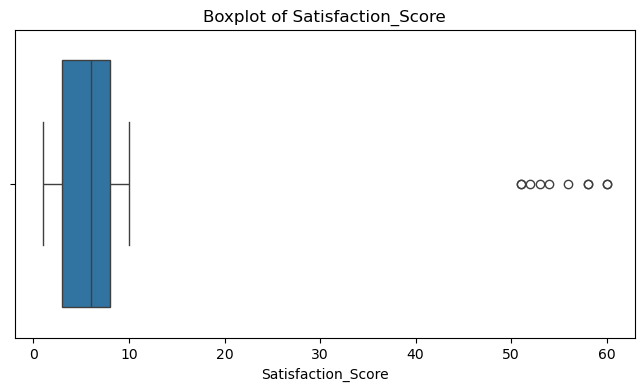

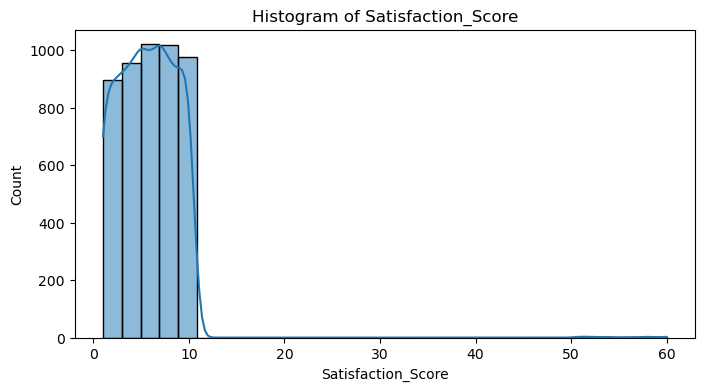

In [13]:
# 1. Descriptive Statistics: Check for the range, mean, and quartiles of the 'Satisfaction_Score'
print(data1['Satisfaction_Score'].describe())

# 2. IQR Method: Detect Outliers using IQR
Q1 = data1['Satisfaction_Score'].quantile(0.25)
Q3 = data1['Satisfaction_Score'].quantile(0.75)
IQR = Q3 - Q1
# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Find outliers
outliers = data1[(data1['Satisfaction_Score'] < lower_bound) | (data1['Satisfaction_Score'] > upper_bound)]
outliers_sorted = outliers[['Satisfaction_Score']].sort_values(by='Satisfaction_Score', ascending=False)
# Print the sorted outliers
print("\nOutliers detected using IQR method (sorted by Satisfaction_Score):")
print(outliers_sorted)


# 3. Calculate the Z-scores for Satisfaction_Score
z_scores = zscore(data1['Satisfaction_Score'])
# Find rows with Z-scores greater than 3 or less than -3
outliers_zscore = data1[abs(z_scores) > 3]
# Optionally: show how many outliers there are
print(f"\nNumber of outliers (based on Z-score): {outliers_zscore.shape[0]}")
print("Outliers detected (based on Z-score):")
print(outliers_zscore)

# 4. Boxplot visualization: Visualize outliers with a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=data1['Satisfaction_Score'])
plt.title('Boxplot of Satisfaction_Score')
plt.show()

# 5. Histogram: Visualize the distribution of the Satisfaction_Score
plt.figure(figsize=(8, 4))
sns.histplot(data1['Satisfaction_Score'], bins=30, kde=True)
plt.title('Histogram of Satisfaction_Score')
plt.show()

    Satisfaction_Score Boxplot:
        * The boxplot confirms the normal distribution, showing that the majority of the data points fall within the interquartile range (IQR).
        * The presence of outliers beyond the whiskers indicates a few customers with exceptionally high satisfaction scores.
    
    Satisfaction_Score Histogram:
        * The histogram shows a normal distribution with a peak around 7, indicating that most customers have a satisfaction score close to 7.
        * There is a long tail towards the right, suggesting the presence of some customers with very high satisfaction scores.

# Skewness analysis

In [14]:
# Check skewness of Transaction_Amount
skewness = data3['Transaction_Amount'].skew()
print(f"Skewness of Transaction_Amount: {skewness}")

# Function to compare mean and median values of Transaction_Amount
def check_mean_median(data, column_name):
    """
    This function checks if the mean is greater than the median for a given column.
    It prints the mean, median, and their relationship.
    
    Parameters:
    - data (pandas DataFrame): The DataFrame containing the data.
    - column_name (str): The name of the column to check.
    """
    # Get descriptive statistics for the column
    desc_stats = data[column_name].describe()

    # Extract mean and median
    mean = desc_stats['mean']
    median = desc_stats['50%']
    
    # Print mean and median values
    print(f"\nColumn: {column_name}")
    print(f"Mean: {mean}, Median: {median}")
    
    # Check if the mean is greater than the median
    if mean > median:
        print(f"The column '{column_name}' is likely right-skewed (positive skew).")
    elif mean < median:
        print(f"The column '{column_name}' is likely left-skewed (negative skew).")
    else:
        print(f"The column '{column_name}' is roughly symmetric.")
    
# Check mean/median of Transaction_Amount
check_mean_median(data3, 'Transaction_Amount')

Skewness of Transaction_Amount: 26.138735355941975

Column: Transaction_Amount
Mean: 3102.050816326531, Median: 2481.5
The column 'Transaction_Amount' is likely right-skewed (positive skew).


# Handling Satisfaction_Score "outliers"

In [15]:
# Load the transaction data
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_deleted_missing_records.csv')

# Filter out rows where Satisfaction_Score is not in the range 1 to 10
data1_cleaned = data1[(data1['Satisfaction_Score'] >= 1) & (data1['Satisfaction_Score'] <= 10)]

# Save the cleaned dataset to a CSV file
dataset_name = 'customer_feedback_data'  
cleaned_filename = f'/Users/fritzcabalhin/Desktop/3. Data Mining Principles/{dataset_name}_outlier_treatment.csv'

# Write the cleaned data to a CSV file without the index
data1_cleaned.to_csv(cleaned_filename, index=False)

print(f"Cleaned dataset saved to {cleaned_filename}")

Cleaned dataset saved to /Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_outlier_treatment.csv


In [16]:
# Load the datasets
data1 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_outlier_treatment.csv')
data2 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/product_offering_data_deleted_missing_records.csv')
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deleted_missing_records.csv')

# Define datasets and dataset_names
datasets = [data1, data2, data3] #replace
dataset_names = ['customer_feedback_data','product_offering_data','transaction_data']
dataset_titles = ['Customer Feedback','Product Offering','Transactions']

for df, dataset_title in zip(datasets, dataset_titles):
    print(f"\n {dataset_title} statistics for numerical and categorical columns: \n{df.describe(include='all')}")


 Customer Feedback statistics for numerical and categorical columns: 
        Customer_ID  Satisfaction_Score Feedback_Comments  Likelihood_to_Recommend
count   4859.000000         4859.000000              4859              4859.000000
unique          NaN                 NaN                 5                      NaN
top             NaN                 NaN      Good service                      NaN
freq            NaN                 NaN              1448                      NaN
mean     500.660424            5.591068               NaN                 5.562873
std      288.496413            2.830044               NaN                 2.870670
min        1.000000            1.000000               NaN                 1.000000
25%      252.000000            3.000000               NaN                 3.000000
50%      499.000000            6.000000               NaN                 6.000000
75%      749.000000            8.000000               NaN                 8.000000
max     1000.000

# Standardization and Normalization

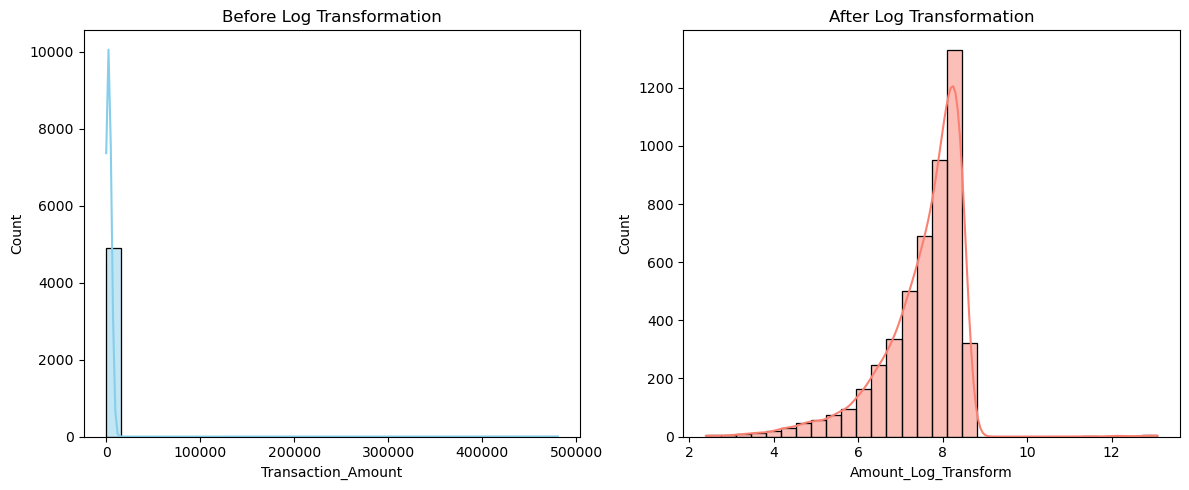


Summary of Scaled Transaction Amount:
count    4.900000e+03
mean     2.320140e-17
std      1.000102e+00
min     -5.255090e+00
25%     -4.182315e-01
50%      2.888178e-01
75%      7.000414e-01
max      5.675200e+00
Name: Transaction_Amount_Scaled, dtype: float64


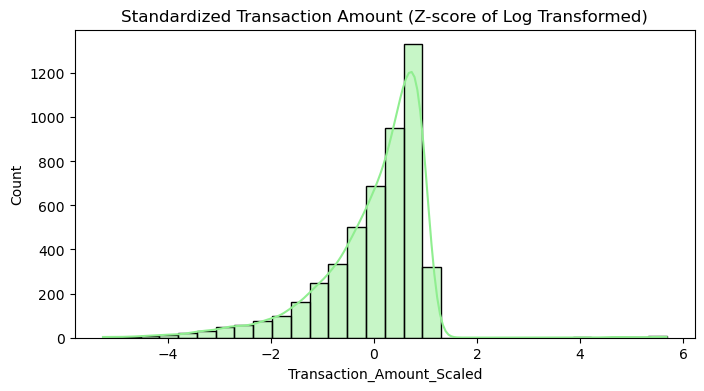


✅ Scaled and normalized transaction data saved to:
/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_scaling_normalization.csv


In [17]:
# Load dataset
data3 = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_deleted_missing_records.csv')

# Step 1: Log Transformation to reduce right skewness
# We use log1p to handle values like log(0) safely
data3["Amount_Log_Transform"] = np.log1p(data3["Transaction_Amount"])

# Optional: Visualize before and after log transformation
plt.figure(figsize=(12, 5))

# Histogram before log
plt.subplot(1, 2, 1)
sns.histplot(data3["Transaction_Amount"], bins=30, kde=True, color='skyblue')
plt.title('Before Log Transformation')

# Histogram after log
plt.subplot(1, 2, 2)
sns.histplot(data3["Amount_Log_Transform"], bins=30, kde=True, color='salmon')
plt.title('After Log Transformation')

plt.tight_layout()
plt.show()

# Step 2: Standardization (Z-score) on the log-transformed values
scaler = StandardScaler()
data3["Transaction_Amount_Scaled"] = scaler.fit_transform(data3[["Amount_Log_Transform"]])

# Optional: Check summary statistics of scaled data
print("\nSummary of Scaled Transaction Amount:")
print(data3["Transaction_Amount_Scaled"].describe())

# Optional: Histogram of standardized values
plt.figure(figsize=(8, 4))
sns.histplot(data3["Transaction_Amount_Scaled"], bins=30, kde=True, color='lightgreen')
plt.title('Standardized Transaction Amount (Z-score of Log Transformed)')
plt.show()

# Step 3: Save the transformed dataset
output_path = "/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_scaling_normalization.csv"
data3.to_csv(output_path, index=False)

print(f"\n✅ Scaled and normalized transaction data saved to:\n{output_path}")

# Creating New Features (Transaction Data)

In [18]:
# Load the cleaned & scaled transaction dataset
create_feature_data3 = pd.read_csv("/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_data_scaling_normalization.csv")

# Make sure Transaction_Date is datetime format
create_feature_data3['Transaction_Date'] = pd.to_datetime(create_feature_data3['Transaction_Date'])

# Create Month-Year column
create_feature_data3['Transaction_Month'] = create_feature_data3['Transaction_Date'].dt.to_period('M')

# Define reference date (latest transaction date in the dataset)
reference_date = create_feature_data3['Transaction_Date'].max()

# Add Max and Min Spend to aggregation
agg_feature_data3 = create_feature_data3.groupby('Customer_ID').agg(
    Total_Transactions=('Transaction_ID', 'count'),
    Total_Spend=('Transaction_Amount', 'sum'),
    Average_Spend=('Transaction_Amount', 'mean'),
    Spend_StdDev=('Transaction_Amount', 'std'),
    Max_Spend=('Transaction_Amount', 'max'),
    Min_Spend=('Transaction_Amount', 'min'),
    First_Transaction_Date=('Transaction_Date', 'min'),
    Last_Transaction_Date=('Transaction_Date', 'max'),
    Active_Months=('Transaction_Month', pd.Series.nunique)
).reset_index()

# Recalculate recency and average frequency
agg_feature_data3['Recency_Days'] = (reference_date - agg_feature_data3['Last_Transaction_Date']).dt.days
agg_feature_data3['Avg_Transactions_per_Month'] = agg_feature_data3['Total_Transactions'] / agg_feature_data3['Active_Months']

# Preview output
agg_feature_data3.head()

,Customer_ID,Total_Transactions,Total_Spend,Average_Spend,Spend_StdDev,Max_Spend,Min_Spend,First_Transaction_Date,Last_Transaction_Date,Active_Months,Recency_Days,Avg_Transactions_per_Month
0,1,6,16836.0,2806.0,2062.310646,4993.0,156.0,2023-01-02 04:00:00,2023-07-02 03:00:00,4,26,1.500000
1,2,2,4907.0,2453.5,560.735677,2850.0,2057.0,2023-02-06 04:00:00,2023-05-21 23:00:00,2,67,1.000000
2,3,1,1538.0,1538.0,NaN,1538.0,1538.0,2023-02-27 23:00:00,2023-02-27 23:00:00,1,150,1.000000
3,4,2,8295.0,4147.5,832.264681,4736.0,3559.0,2023-01-22 15:00:00,2023-06-30 01:00:00,2,28,1.000000
4,5,5,14798.0,2959.6,1386.584040,4878.0,1508.0,2023-02-19 15:00:00,2023-07-27 00:00:00,3,1,1.666667


# Transforming Categorical Features (Transaction Data)

In [19]:
# One-hot encoding of Transaction_Type per customer
transaction_type_encoded = pd.crosstab(create_feature_data3['Customer_ID'], create_feature_data3['Transaction_Type'])

# Rename columns for clarity
transaction_type_encoded.columns = [f'Num_{col.replace(" ", "_")}' for col in transaction_type_encoded.columns]

# Merge encoded features with aggregated features
transform_cat_data3 = pd.merge(agg_feature_data3, transaction_type_encoded, on='Customer_ID', how='left')

# Add transaction type percentages (can be useful for clustering later)
transform_cat_data3['Pct_Purchase'] = transform_cat_data3.get('Num_Purchase', 0) / transform_cat_data3['Total_Transactions']
transform_cat_data3['Pct_Investment'] = transform_cat_data3.get('Num_Investment', 0) / transform_cat_data3['Total_Transactions']
transform_cat_data3['Pct_Bill_Payment'] = transform_cat_data3.get('Num_Bill_Payment', 0) / transform_cat_data3['Total_Transactions']
transform_cat_data3['Pct_Loan_Payment'] = transform_cat_data3.get('Num_Loan_Payment', 0) / transform_cat_data3['Total_Transactions']

# Final preview of customer features
transform_cat_data3.head()

,Customer_ID,Total_Transactions,Total_Spend,Average_Spend,Spend_StdDev,Max_Spend,Min_Spend,First_Transaction_Date,Last_Transaction_Date,Active_Months,Recency_Days,Avg_Transactions_per_Month,Num_Bill_Payment,Num_Investment,Num_Loan_Payment,Num_Purchase,Pct_Purchase,Pct_Investment,Pct_Bill_Payment,Pct_Loan_Payment
0,1,6,16836.0,2806.0,2062.310646,4993.0,156.0,2023-01-02 04:00:00,2023-07-02 03:00:00,4,26,1.500000,3,1,1,1,0.166667,0.166667,0.5,0.166667
1,2,2,4907.0,2453.5,560.735677,2850.0,2057.0,2023-02-06 04:00:00,2023-05-21 23:00:00,2,67,1.000000,1,0,1,0,0.000000,0.000000,0.5,0.500000
2,3,1,1538.0,1538.0,NaN,1538.0,1538.0,2023-02-27 23:00:00,2023-02-27 23:00:00,1,150,1.000000,1,0,0,0,0.000000,0.000000,1.0,0.000000
3,4,2,8295.0,4147.5,832.264681,4736.0,3559.0,2023-01-22 15:00:00,2023-06-30 01:00:00,2,28,1.000000,0,0,1,1,0.500000,0.000000,0.0,0.500000
4,5,5,14798.0,2959.6,1386.584040,4878.0,1508.0,2023-02-19 15:00:00,2023-07-27 00:00:00,3,1,1.666667,2,1,0,2,0.400000,0.200000,0.4,0.000000


In [20]:
# Export new features
transform_cat_data3.to_csv("transaction_feature_engineering.csv", index=False)
print("✅ Engineered features dataset saved successfully.")

✅ Engineered features dataset saved successfully.


# Optional Feature Engineering (Customer Feedback Data)

In [21]:
# Load the feedback dataset
create_feature_data1 = pd.read_csv("/Users/fritzcabalhin/Desktop/3. Data Mining Principles/customer_feedback_data_outlier_treatment.csv")

# Satisfaction flags
create_feature_data1['High_Satisfaction_Flag'] = (create_feature_data1['Satisfaction_Score'] >= 8).astype(int)
create_feature_data1['Low_Satisfaction_Flag'] = (create_feature_data1['Satisfaction_Score'] <= 3).astype(int)

# Satisfaction level (Low, Medium, High)
def satisfaction_level(score):
    if score <= 3:
        return 'Low'
    elif score <= 7:
        return 'Medium'
    else:
        return 'High'

create_feature_data1['Satisfaction_Level'] = create_feature_data1['Satisfaction_Score'].apply(satisfaction_level)

# NPS Segment classification (Detractor, Passive, Promoter)
def nps_segment(score):
    if score >= 9:
        return 'Promoter'
    elif score >= 7:
        return 'Passive'
    else:
        return 'Detractor'

create_feature_data1['NPS_Segment'] = create_feature_data1['Likelihood_to_Recommend'].apply(nps_segment)

# Ordinal encoding of Feedback_Comments sentiment (optional use)
sentiment_map = {
    'Unsatisfactory': 1,
    'Needs improvement': 2,
    'Good service': 3,
    'Very satisfied': 4,
    'Excellent': 5
}
create_feature_data1['Feedback_Sentiment_Score'] = create_feature_data1['Feedback_Comments'].map(sentiment_map)

# Preview updated dataset
create_feature_data1.head()

,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend,High_Satisfaction_Flag,Low_Satisfaction_Flag,Satisfaction_Level,NPS_Segment,Feedback_Sentiment_Score
0,1,10.0,Very satisfied,9,1,0,High,Promoter,4
1,2,3.0,Very satisfied,3,0,1,Low,Detractor,4
2,3,10.0,Very satisfied,1,1,0,High,Detractor,4
3,4,7.0,Needs improvement,4,0,0,Medium,Detractor,2
4,5,8.0,Unsatisfactory,7,1,0,High,Passive,1


In [22]:
# Group by Customer_ID to create customer-level sentiment features
agg_feature_data1 = create_feature_data1.groupby('Customer_ID').agg(
    Avg_Satisfaction_Score=('Satisfaction_Score', 'mean'),
    Std_Satisfaction_Score=('Satisfaction_Score', 'std'),
    Max_Satisfaction_Score=('Satisfaction_Score', 'max'),
    Min_Satisfaction_Score=('Satisfaction_Score', 'min'),
    Avg_Likelihood_to_Recommend=('Likelihood_to_Recommend', 'mean'),
    N_Feedback_Entries=('Satisfaction_Score', 'count'),
    Avg_Sentiment_Score=('Feedback_Sentiment_Score', 'mean')  # optional
).reset_index()

# Preview
agg_feature_data1.head()


agg_feature_data1.to_csv("feedback_feature_engineering.csv", index=False)
print("✅ Engineered features dataset saved successfully.")

✅ Engineered features dataset saved successfully.


In [23]:
# Complete column and data type for Transaction Data
transform_cat_data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Customer_ID                 993 non-null    int64         
 1   Total_Transactions          993 non-null    int64         
 2   Total_Spend                 993 non-null    float64       
 3   Average_Spend               993 non-null    float64       
 4   Spend_StdDev                961 non-null    float64       
 5   Max_Spend                   993 non-null    float64       
 6   Min_Spend                   993 non-null    float64       
 7   First_Transaction_Date      993 non-null    datetime64[ns]
 8   Last_Transaction_Date       993 non-null    datetime64[ns]
 9   Active_Months               993 non-null    int64         
 10  Recency_Days                993 non-null    int64         
 11  Avg_Transactions_per_Month  993 non-null    float64       

In [24]:
# Statistics for the aggregated Transaction Data (customer-grain)
transform_cat_data3.describe()

,Customer_ID,Total_Transactions,Total_Spend,Average_Spend,Spend_StdDev,Max_Spend,Min_Spend,First_Transaction_Date,Last_Transaction_Date,Active_Months,Recency_Days,Avg_Transactions_per_Month,Num_Bill_Payment,Num_Investment,Num_Loan_Payment,Num_Purchase,Pct_Purchase,Pct_Investment,Pct_Bill_Payment,Pct_Loan_Payment
count,993.000000,993.000000,993.000000,993.000000,961.000000,993.000000,993.000000,993,993,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,500.871098,4.934542,15307.199396,3071.564449,2667.035108,7025.695871,1015.244713,2023-02-10 18:32:30.453172480,2023-06-18 11:59:09.244712960,3.554884,39.325277,1.382897,1.217523,1.231621,1.262840,1.222558,0.250134,0.255556,0.245026,0.249285
min,1.000000,1.000000,76.000000,76.000000,17.677670,76.000000,10.000000,2023-01-01 00:00:00,2023-01-11 08:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,251.000000,3.000000,7632.000000,2014.000000,1046.274852,3592.000000,324.000000,2023-01-12 23:00:00,2023-06-01 18:00:00,3.000000,11.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,502.000000,5.000000,11818.000000,2457.875000,1359.570731,4347.000000,745.000000,2023-01-29 09:00:00,2023-06-29 08:00:00,4.000000,28.000000,1.333333,1.000000,1.000000,1.000000,1.000000,0.250000,0.250000,0.222222,0.250000
75%,750.000000,6.000000,16146.000000,2948.000000,1652.998632,4734.000000,1369.000000,2023-02-27 10:00:00,2023-07-16 11:00:00,4.000000,56.000000,1.600000,2.000000,2.000000,2.000000,2.000000,0.400000,0.400000,0.375000,0.400000
max,1000.000000,13.000000,489516.000000,144144.000000,246605.944876,480300.000000,4993.000000,2023-07-26 15:00:00,2023-07-28 07:00:00,7.000000,197.000000,3.000000,7.000000,5.000000,7.000000,6.000000,1.000000,1.000000,1.000000,1.000000
std,288.630791,2.158709,33674.460932,6983.989570,14736.514750,32704.960832,952.071749,NaN,NaN,1.274462,37.046695,0.367627,1.146090,1.059104,1.140528,1.055809,0.210780,0.222269,0.227824,0.221776


In [25]:
# Complete column and data type for Customer Feedback Data
agg_feature_data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  1000 non-null   int64  
 1   Avg_Satisfaction_Score       1000 non-null   float64
 2   Std_Satisfaction_Score       978 non-null    float64
 3   Max_Satisfaction_Score       1000 non-null   float64
 4   Min_Satisfaction_Score       1000 non-null   float64
 5   Avg_Likelihood_to_Recommend  1000 non-null   float64
 6   N_Feedback_Entries           1000 non-null   int64  
 7   Avg_Sentiment_Score          1000 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 62.6 KB


In [26]:
# Statistics for the aggregated Customer Feedback Data (customer-grain)
agg_feature_data1.describe()

,Customer_ID,Avg_Satisfaction_Score,Std_Satisfaction_Score,Max_Satisfaction_Score,Min_Satisfaction_Score,Avg_Likelihood_to_Recommend,N_Feedback_Entries,Avg_Sentiment_Score
count,1000.000000,1000.000000,978.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,5.594855,2.690183,8.581000,2.54500,5.565752,4.859000,2.806854
std,288.819436,1.401064,0.917253,1.709492,1.76326,1.492734,1.965447,0.630940
min,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000
25%,250.750000,4.702381,2.121320,8.000000,1.00000,4.500000,3.000000,2.400000
50%,500.500000,5.585714,2.774887,9.000000,2.00000,5.666667,5.000000,2.800000
75%,750.250000,6.500000,3.304038,10.000000,3.00000,6.559524,6.000000,3.200000
max,1000.000000,10.000000,6.363961,10.000000,10.00000,10.000000,13.000000,5.000000


# Scaling and Normalization (Final)

In [27]:
# Create a copy of data3
data3_scaled = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_feature_engineering.csv')

# Define the columns to scale using Z-Score and Min-Max
columns_to_standardize = [
    'Total_Transactions', 'Total_Spend', 'Average_Spend', 'Spend_StdDev', 
    'Max_Spend', 'Min_Spend', 'Avg_Transactions_per_Month', 'Recency_Days'
]

columns_to_minmax = [
    'Pct_Purchase', 'Pct_Investment', 'Pct_Bill_Payment', 'Pct_Loan_Payment'
]

# Initialize the StandardScaler and MinMaxScaler
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Apply Z-Score Standardization to the selected columns
data3_scaled[columns_to_standardize] = standard_scaler.fit_transform(data3_scaled[columns_to_standardize])

# Apply Min-Max Scaling to the percentage columns
data3_scaled[columns_to_minmax] = minmax_scaler.fit_transform(data3_scaled[columns_to_minmax])

# Save the scaled dataset to a CSV file
output_path = ('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_scaled_normalized.csv')
data3_scaled.to_csv(output_path, index=False)

print(f"Scaled and normalized dataset saved to {output_path}")

Scaled and normalized dataset saved to /Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_scaled_normalized.csv


In [28]:
# Create a copy of the dataset to avoid modifying the original
data1_scaled = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/feedback_feature_engineering.csv')

# Define columns for Z-Score Normalization
columns_to_standardize = [
    'Std_Satisfaction_Score', 'N_Feedback_Entries', 'Avg_Sentiment_Score'
]

# Define columns for Min-Max Scaling (Optional, but recommended for range 1-10)
columns_to_minmax = [
    'Avg_Satisfaction_Score', 'Max_Satisfaction_Score', 
    'Min_Satisfaction_Score', 'Avg_Likelihood_to_Recommend'
]

# Initialize the scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Apply Z-Score Normalization to the specified columns
data1_scaled[columns_to_standardize] = standard_scaler.fit_transform(data1_scaled[columns_to_standardize])

# Apply Min-Max Scaling to the specified columns
data1_scaled[columns_to_minmax] = minmax_scaler.fit_transform(data1_scaled[columns_to_minmax])

# Save the scaled and normalized dataset to a CSV file
output_path = ('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/feedback_scaled_normalized.csv')
data1_scaled.to_csv(output_path, index=False)

print(f"Scaled and normalized dataset saved to {output_path}")

Scaled and normalized dataset saved to /Users/fritzcabalhin/Desktop/3. Data Mining Principles/feedback_scaled_normalized.csv


# EDA - Data Overview

In [29]:
data1_scaled.describe()

,Customer_ID,Avg_Satisfaction_Score,Std_Satisfaction_Score,Max_Satisfaction_Score,Min_Satisfaction_Score,Avg_Likelihood_to_Recommend,N_Feedback_Entries,Avg_Sentiment_Score
count,1000.000000,1000.000000,9.780000e+02,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03
mean,500.500000,0.510539,1.453053e-16,0.842333,0.171667,0.507306,-7.105427e-18,3.410605e-16
std,288.819436,0.155674,1.000512e+00,0.189944,0.195918,0.165859,1.000500e+00,1.000500e+00
min,1.000000,0.000000,-2.934369e+00,0.000000,0.000000,0.000000,-1.964403e+00,-2.865183e+00
25%,250.750000,0.411376,-6.204982e-01,0.777778,0.000000,0.388889,-9.463141e-01,-6.451602e-01
50%,500.500000,0.509524,9.239269e-02,0.888889,0.111111,0.518519,7.177530e-02,-1.086812e-02
75%,750.250000,0.611111,6.695739e-01,1.000000,0.222222,0.617725,5.808200e-01,6.234240e-01
max,1000.000000,1.000000,4.007244e+00,1.000000,1.000000,1.000000,4.144133e+00,3.477738e+00


In [30]:
print(data1_scaled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  1000 non-null   int64  
 1   Avg_Satisfaction_Score       1000 non-null   float64
 2   Std_Satisfaction_Score       978 non-null    float64
 3   Max_Satisfaction_Score       1000 non-null   float64
 4   Min_Satisfaction_Score       1000 non-null   float64
 5   Avg_Likelihood_to_Recommend  1000 non-null   float64
 6   N_Feedback_Entries           1000 non-null   float64
 7   Avg_Sentiment_Score          1000 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 62.6 KB
None


In [31]:
data3_scaled.describe()

,Customer_ID,Total_Transactions,Total_Spend,Average_Spend,Spend_StdDev,Max_Spend,Min_Spend,Active_Months,Recency_Days,Avg_Transactions_per_Month,Num_Bill_Payment,Num_Investment,Num_Loan_Payment,Num_Purchase,Pct_Purchase,Pct_Investment,Pct_Bill_Payment,Pct_Loan_Payment
count,993.000000,9.930000e+02,9.930000e+02,9.930000e+02,9.610000e+02,9.930000e+02,9.930000e+02,993.000000,9.930000e+02,9.930000e+02,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,500.871098,6.082189e-17,8.049955e-18,2.862206e-17,-1.663602e-17,-8.944395e-18,-2.862206e-17,3.554884,-6.887184e-17,-4.364865e-16,1.217523,1.231621,1.262840,1.222558,0.250134,0.255556,0.245026,0.249285
std,288.630791,1.000504e+00,1.000504e+00,1.000504e+00,1.000521e+00,1.000504e+00,1.000504e+00,1.274462,1.000504e+00,1.000504e+00,1.146090,1.059104,1.140528,1.055809,0.210780,0.222269,0.227824,0.221776
min,1.000000,-1.823555e+00,-4.525351e-01,-4.291349e-01,-1.798754e-01,-2.126038e-01,-1.056382e+00,1.000000,-1.062041e+00,-1.042061e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,251.000000,-8.966083e-01,-2.280383e-01,-1.515033e-01,-1.100399e-01,-1.050430e-01,-7.264085e-01,3.000000,-7.649684e-01,-1.042061e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,502.000000,3.033813e-02,-1.036678e-01,-8.791518e-02,-8.876897e-02,-8.194615e-02,-2.839921e-01,4.000000,-3.058568e-01,-1.348883e-01,1.000000,1.000000,1.000000,1.000000,0.250000,0.250000,0.222222,0.250000
75%,750.000000,4.938113e-01,2.492165e-02,-1.770145e-02,-6.884698e-02,-7.010712e-02,3.717509e-01,4.000000,4.503270e-01,5.908501e-01,2.000000,2.000000,2.000000,2.000000,0.400000,0.400000,0.375000,0.400000
max,1000.000000,3.738124e+00,1.408925e+01,2.020958e+01,1.656198e+01,1.447832e+01,4.180105e+00,7.000000,4.258252e+00,4.400977e+00,7.000000,5.000000,7.000000,6.000000,1.000000,1.000000,1.000000,1.000000


In [32]:
print(data3_scaled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 993 non-null    int64  
 1   Total_Transactions          993 non-null    float64
 2   Total_Spend                 993 non-null    float64
 3   Average_Spend               993 non-null    float64
 4   Spend_StdDev                961 non-null    float64
 5   Max_Spend                   993 non-null    float64
 6   Min_Spend                   993 non-null    float64
 7   First_Transaction_Date      993 non-null    object 
 8   Last_Transaction_Date       993 non-null    object 
 9   Active_Months               993 non-null    int64  
 10  Recency_Days                993 non-null    float64
 11  Avg_Transactions_per_Month  993 non-null    float64
 12  Num_Bill_Payment            993 non-null    int64  
 13  Num_Investment              993 non

# Data Prep for EDA and Clustering

In [47]:
data3_scaled = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_scaled_normalized.csv')
data1_scaled = pd.read_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/feedback_scaled_normalized.csv')

# Drop ID and datetime columns
data3_scaled_cleaned = data3_scaled.drop(columns=[
    "Customer_ID", "First_Transaction_Date", "Last_Transaction_Date"
])
data1_scaled_cleaned = data1_scaled.drop(columns=["Customer_ID"])

# Impute missing values using median
median_spend_stddev = data3_scaled_cleaned["Spend_StdDev"].median()
data3_scaled_cleaned["Spend_StdDev"] = data3_scaled_cleaned["Spend_StdDev"].fillna(median_spend_stddev)

median_satscore_stddev = data1_scaled_cleaned["Std_Satisfaction_Score"].median()
data1_scaled_cleaned["Std_Satisfaction_Score"] = data1_scaled_cleaned["Std_Satisfaction_Score"].fillna(median_satscore_stddev)

# Save cleaned data to CSV
data3_scaled_cleaned.to_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/transaction_scaled_cleaned.csv', index=False)
data1_scaled_cleaned.to_csv('/Users/fritzcabalhin/Desktop/3. Data Mining Principles/feedback_scaled_cleaned.csv', index=False)

In [48]:
data3_scaled_cleaned.describe()

,Total_Transactions,Total_Spend,Average_Spend,Spend_StdDev,Max_Spend,Min_Spend,Active_Months,Recency_Days,Avg_Transactions_per_Month,Num_Bill_Payment,Num_Investment,Num_Loan_Payment,Num_Purchase,Pct_Purchase,Pct_Investment,Pct_Bill_Payment,Pct_Loan_Payment
count,9.930000e+02,9.930000e+02,9.930000e+02,993.000000,9.930000e+02,9.930000e+02,993.000000,9.930000e+02,9.930000e+02,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,3.935534e-17,1.878323e-17,4.561641e-17,-0.002861,3.398870e-17,-1.431103e-17,3.554884,-7.155516e-17,-4.364865e-16,1.217523,1.231621,1.262840,1.222558,0.250134,0.255556,0.245026,0.249285
std,1.000504e+00,1.000504e+00,1.000504e+00,0.984376,1.000504e+00,1.000504e+00,1.274462,1.000504e+00,1.000504e+00,1.146090,1.059104,1.140528,1.055809,0.210780,0.222269,0.227824,0.221776
min,-1.823555e+00,-4.525351e-01,-4.291349e-01,-0.179875,-2.126038e-01,-1.056382e+00,1.000000,-1.062041e+00,-1.042061e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.966083e-01,-2.280383e-01,-1.515033e-01,-0.109246,-1.050430e-01,-7.264085e-01,3.000000,-7.649684e-01,-1.042061e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.033813e-02,-1.036678e-01,-8.791518e-02,-0.088769,-8.194615e-02,-2.839921e-01,4.000000,-3.058568e-01,-1.348883e-01,1.000000,1.000000,1.000000,1.000000,0.250000,0.250000,0.222222,0.250000
75%,4.938113e-01,2.492165e-02,-1.770145e-02,-0.069452,-7.010712e-02,3.717509e-01,4.000000,4.503270e-01,5.908501e-01,2.000000,2.000000,2.000000,2.000000,0.400000,0.400000,0.375000,0.400000
max,3.738124e+00,1.408925e+01,2.020958e+01,16.561984,1.447832e+01,4.180105e+00,7.000000,4.258252e+00,4.400977e+00,7.000000,5.000000,7.000000,6.000000,1.000000,1.000000,1.000000,1.000000


In [49]:
mean = data3_scaled_cleaned.mean()
median = data3_scaled_cleaned.median()
std_dev = data3_scaled_cleaned.std()

print("Mean:", mean)
print("Median:", median)
print("Standard Deviation:", std_dev)

Mean: Total_Transactions            3.935534e-17
Total_Spend                   1.878323e-17
Average_Spend                 4.561641e-17
Spend_StdDev                 -2.860631e-03
Max_Spend                     3.398870e-17
Min_Spend                    -1.431103e-17
Active_Months                 3.554884e+00
Recency_Days                 -7.155516e-17
Avg_Transactions_per_Month   -4.364865e-16
Num_Bill_Payment              1.217523e+00
Num_Investment                1.231621e+00
Num_Loan_Payment              1.262840e+00
Num_Purchase                  1.222558e+00
Pct_Purchase                  2.501335e-01
Pct_Investment                2.555560e-01
Pct_Bill_Payment              2.450256e-01
Pct_Loan_Payment              2.492849e-01
dtype: float64
Median: Total_Transactions            0.030338
Total_Spend                  -0.103668
Average_Spend                -0.087915
Spend_StdDev                 -0.088769
Max_Spend                    -0.081946
Min_Spend                    -0.283992
Active

In [50]:
data1_scaled_cleaned.describe()

,Avg_Satisfaction_Score,Std_Satisfaction_Score,Max_Satisfaction_Score,Min_Satisfaction_Score,Avg_Likelihood_to_Recommend,N_Feedback_Entries,Avg_Sentiment_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03
mean,0.510539,0.002033,0.842333,0.171667,0.507306,-1.598721e-17,3.446132e-16
std,0.155674,0.989527,0.189944,0.195918,0.165859,1.000500e+00,1.000500e+00
min,0.000000,-2.934369,0.000000,0.000000,0.000000,-1.964403e+00,-2.865183e+00
25%,0.411376,-0.620498,0.777778,0.000000,0.388889,-9.463141e-01,-6.451602e-01
50%,0.509524,0.092393,0.888889,0.111111,0.518519,7.177530e-02,-1.086812e-02
75%,0.611111,0.668100,1.000000,0.222222,0.617725,5.808200e-01,6.234240e-01
max,1.000000,4.007244,1.000000,1.000000,1.000000,4.144133e+00,3.477738e+00


In [51]:
mean = data1_scaled_cleaned.mean()
median = data1_scaled_cleaned.median()
std_dev = data1_scaled_cleaned.std()

print("Mean:", mean)
print("Median:", median)
print("Standard Deviation:", std_dev)

Mean: Avg_Satisfaction_Score         5.105394e-01
Std_Satisfaction_Score         2.032639e-03
Max_Satisfaction_Score         8.423333e-01
Min_Satisfaction_Score         1.716667e-01
Avg_Likelihood_to_Recommend    5.073058e-01
N_Feedback_Entries            -1.598721e-17
Avg_Sentiment_Score            3.446132e-16
dtype: float64
Median: Avg_Satisfaction_Score         0.509524
Std_Satisfaction_Score         0.092393
Max_Satisfaction_Score         0.888889
Min_Satisfaction_Score         0.111111
Avg_Likelihood_to_Recommend    0.518519
N_Feedback_Entries             0.071775
Avg_Sentiment_Score           -0.010868
dtype: float64
Standard Deviation: Avg_Satisfaction_Score         0.155674
Std_Satisfaction_Score         0.989527
Max_Satisfaction_Score         0.189944
Min_Satisfaction_Score         0.195918
Avg_Likelihood_to_Recommend    0.165859
N_Feedback_Entries             1.000500
Avg_Sentiment_Score            1.000500
dtype: float64


# EDA - Univariate Analysis

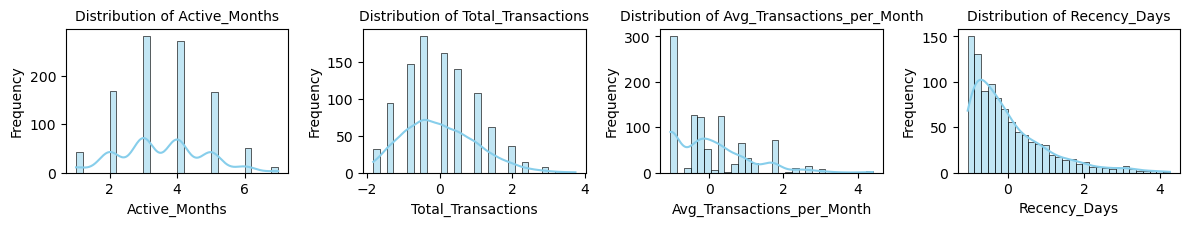

In [52]:
transaction_key_features = [
    'Active_Months', 'Total_Transactions', 'Avg_Transactions_per_Month', 'Recency_Days'
]

plt.figure(figsize=(12, 8))
for i, feature in enumerate(transaction_key_features):
    plt.subplot(4, 4, i + 1)  # change grid
    sns.histplot(data3_scaled_cleaned[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=10)  # smaller font size for title
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

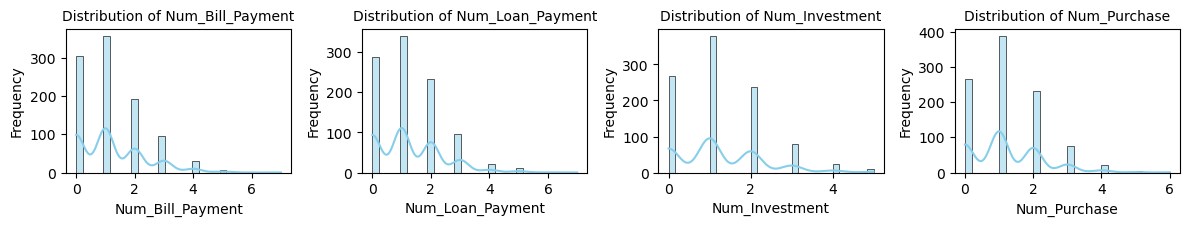

In [53]:
transaction_key_features = [
    'Num_Bill_Payment', 'Num_Loan_Payment', 'Num_Investment', 'Num_Purchase'
]

plt.figure(figsize=(12, 8))
for i, feature in enumerate(transaction_key_features):
    plt.subplot(4, 4, i + 1)  # change grid
    sns.histplot(data3_scaled_cleaned[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=10)  # smaller font size for title
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

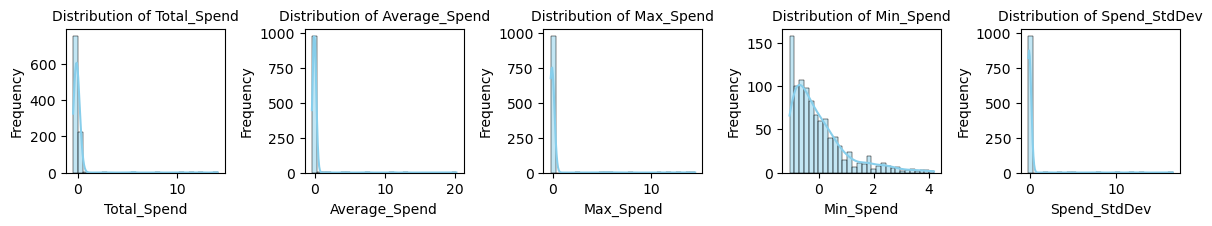

In [54]:
transaction_key_features = [
    'Total_Spend', 'Average_Spend', 'Max_Spend', 'Min_Spend', 'Spend_StdDev'
]

plt.figure(figsize=(12, 8))
for i, feature in enumerate(transaction_key_features):
    plt.subplot(4, 5, i + 1)  # change grid
    sns.histplot(data3_scaled_cleaned[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=10)  # smaller font size for title
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# EDA - Bivariate Analysis

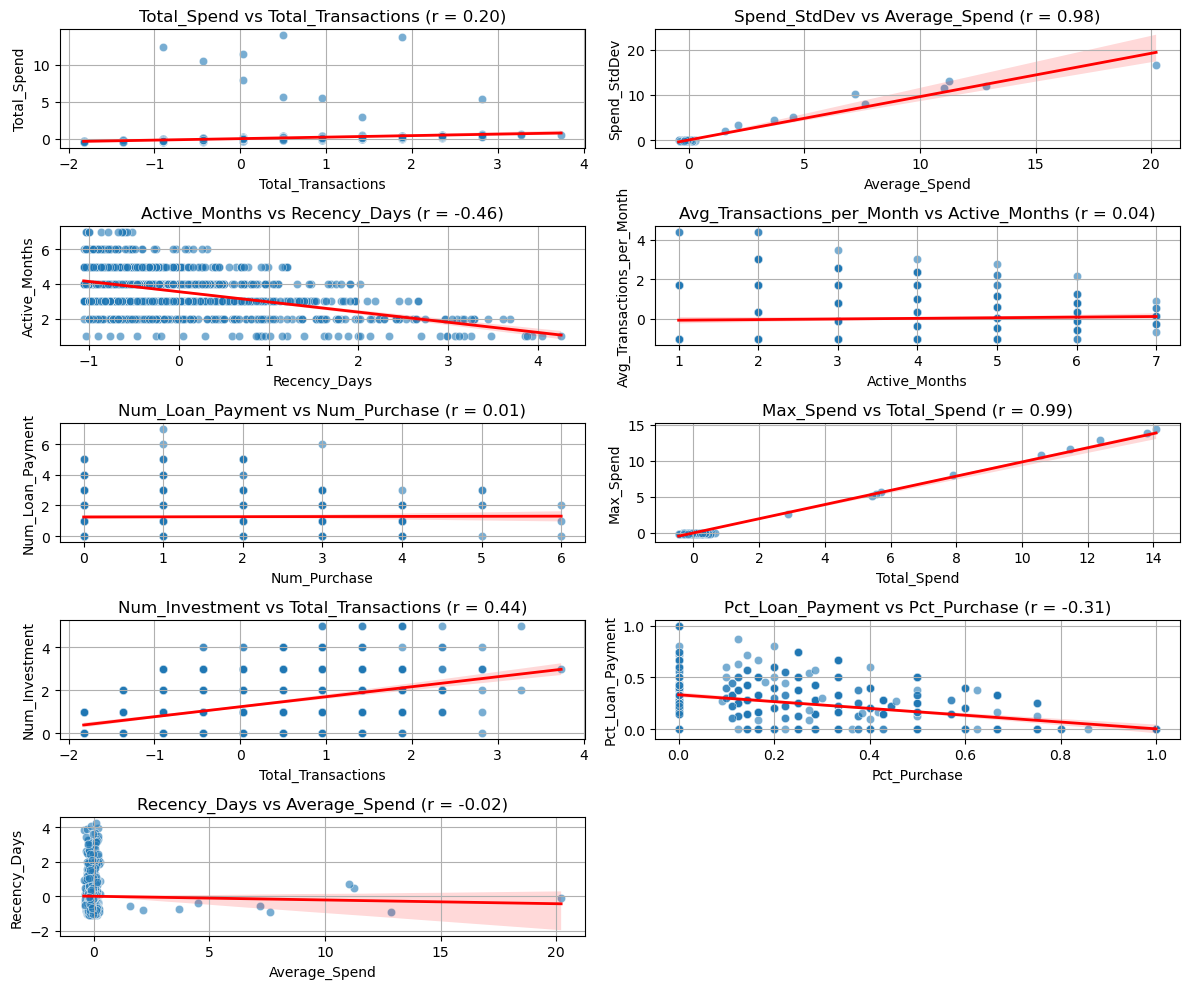

In [55]:
def bivariate_grid(df, pairs, cols=2, add_regression=True, figsize=(12, 10)):
    rows = math.ceil(len(pairs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()  # Flatten in case it's a 2D array

    for i, (x, y) in enumerate(pairs):
        ax = axes[i]
        sns.scatterplot(data=df, x=x, y=y, alpha=0.6, ax=ax)
        
        if add_regression:
            sns.regplot(data=df, x=x, y=y, scatter=False, color='red', line_kws={'linewidth': 2}, ax=ax)
        
        corr, _ = pearsonr(df[x], df[y])
        ax.set_title(f"{y} vs {x} (r = {corr:.2f})")
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.grid(True)
    
    # Hide any unused subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Define your feature pairs
feature_pairs = [
    ('Total_Transactions', 'Total_Spend'), # Tests if more transactions correlate with higher spend — reveals high-volume vs. high-value customers.
    ('Average_Spend', 'Spend_StdDev'), # Highlights consistency vs. inconsistency in customer spending. Stable vs. erratic spenders.
    ('Recency_Days', 'Active_Months'), # Identifies if recent customers are more active. May show inactivity despite high historical use.
    ('Active_Months', 'Avg_Transactions_per_Month'), # Helps uncover engagement intensity: frequent transactions over few months vs. spread over time.
    ('Num_Purchase', 'Num_Loan_Payment'), # Reveals service preferences: who uses the platform mainly for purchases vs. loan payments.
    ('Total_Spend', 'Max_Spend'), # Explores whether big spenders are also “spiky” spenders — large occasional purchases.
    ('Total_Transactions', 'Num_Investment'), # Checks if high activity is driven by investment-related transactions — key for product targeting.
    ('Pct_Purchase', 'Pct_Loan_Payment'), # Investigates transaction type allocation — useful for behavioral segmentation.
    ('Average_Spend', 'Recency_Days') # Reveals whether high average spenders have recently been active — good for churn risk.
]

# Run the visual grid
bivariate_grid(data3_scaled_cleaned, pairs=feature_pairs, cols=2)

# Strategy Behind These Pairings

    1. Behavioral Dimensions: 
        We look for overlaps or differences in:
            Frequency (Total_Transactions, Active_Months)
            Monetary Value (Total_Spend, Average_Spend)
            Consistency (Spend_StdDev, Max_Spend)
            Engagement (Recency_Days)
            Service Usage (Num_Purchase, Pct_*)
    2. Clustering Relevance: These pairs help validate or reject assumptions about natural groupings.
    3. Interpretability: They're intuitive for stakeholders (e.g., marketing or CX teams).



# EDA - Multivariate Analysis

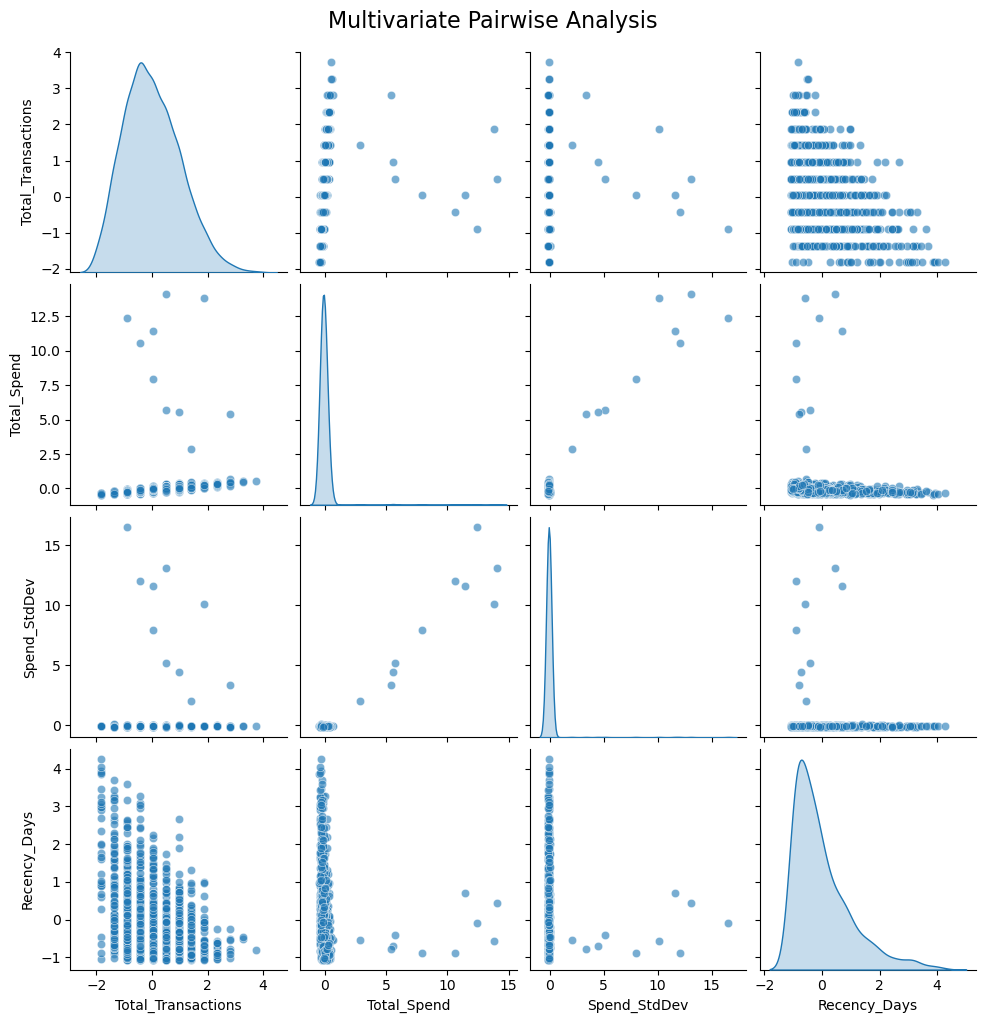

In [56]:
def multivariate_analysis_grid(df, features, hue=None, kind='scatter', diag_kind='kde', palette='Set2'):
    plot_args = {
        'data': df[features + ([hue] if hue else [])],
        'hue': hue,
        'kind': kind,
        'diag_kind': diag_kind,
        'plot_kws': {'alpha': 0.6}
    }
    
    if hue:
        plot_args['palette'] = palette

    sns.pairplot(**plot_args)
    plt.suptitle("Multivariate Pairwise Analysis", y=1.02, fontsize=16)
    plt.show()


multivariate_analysis_grid(
    df=data3_scaled_cleaned,
    features=['Total_Transactions', 'Total_Spend', 'Spend_StdDev', 'Recency_Days']
)


In [57]:
# Variance (spread) of each feature
data3_scaled_cleaned.var().sort_values(ascending=False)

Active_Months                 1.624253
Num_Bill_Payment              1.313523
Num_Loan_Payment              1.300805
Num_Investment                1.121701
Num_Purchase                  1.114733
Avg_Transactions_per_Month    1.001008
Total_Transactions            1.001008
Min_Spend                     1.001008
Average_Spend                 1.001008
Total_Spend                   1.001008
Max_Spend                     1.001008
Recency_Days                  1.001008
Spend_StdDev                  0.968996
Pct_Bill_Payment              0.051904
Pct_Investment                0.049404
Pct_Loan_Payment              0.049185
Pct_Purchase                  0.044428
dtype: float64

In [58]:
data1_scaled_cleaned.var().sort_values(ascending=False)

N_Feedback_Entries             1.001001
Avg_Sentiment_Score            1.001001
Std_Satisfaction_Score         0.979163
Min_Satisfaction_Score         0.038384
Max_Satisfaction_Score         0.036079
Avg_Likelihood_to_Recommend    0.027509
Avg_Satisfaction_Score         0.024234
dtype: float64

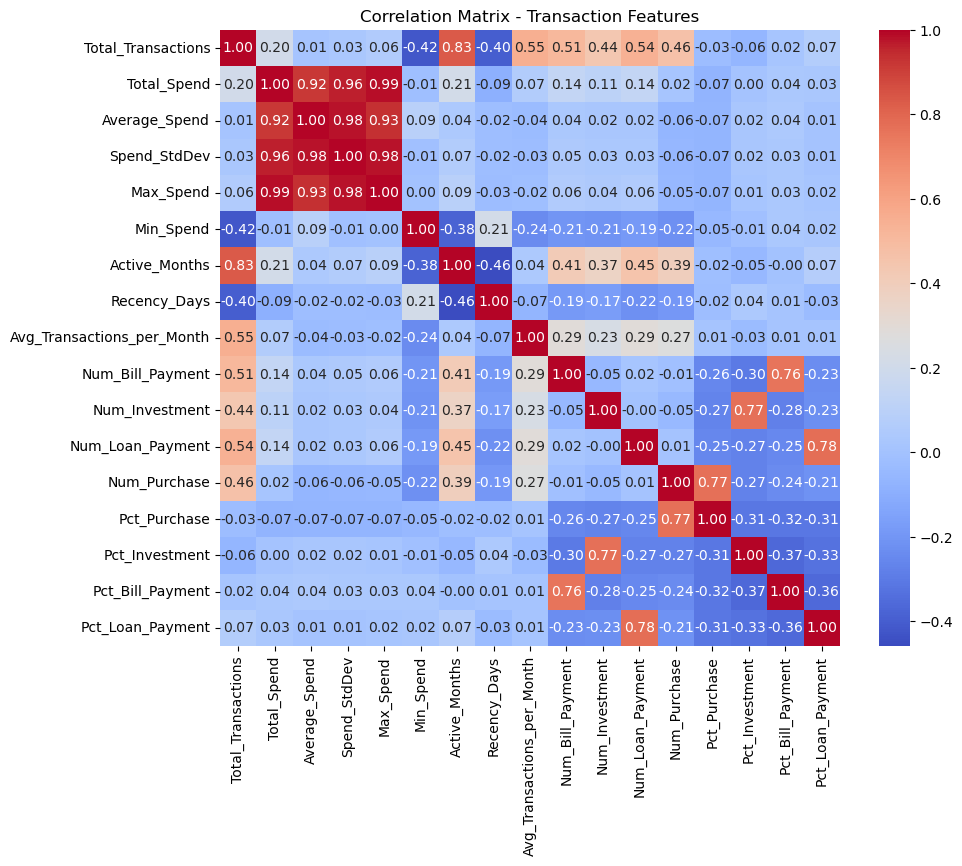

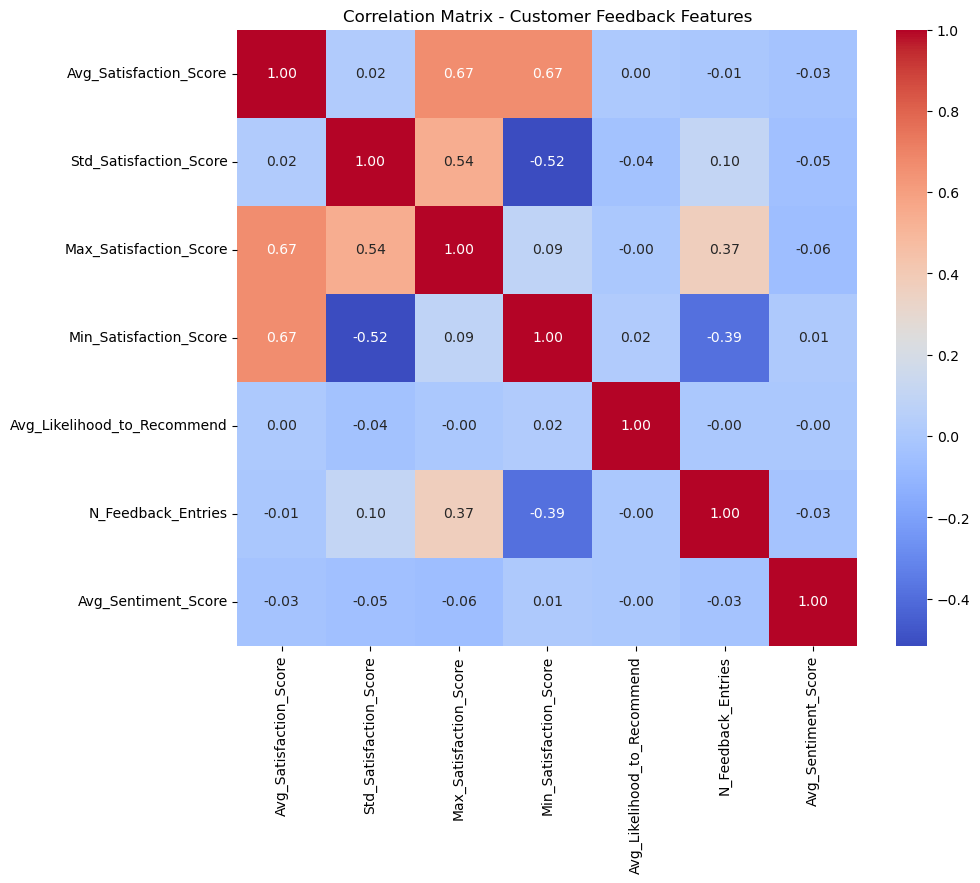

In [59]:
# Transaction features
plt.figure(figsize=(10, 8))
sns.heatmap(data3_scaled_cleaned.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Matrix - Transaction Features")
plt.show()

# Feedback features
plt.figure(figsize=(10, 8))
sns.heatmap(data1_scaled_cleaned.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Matrix - Customer Feedback Features")
plt.show()

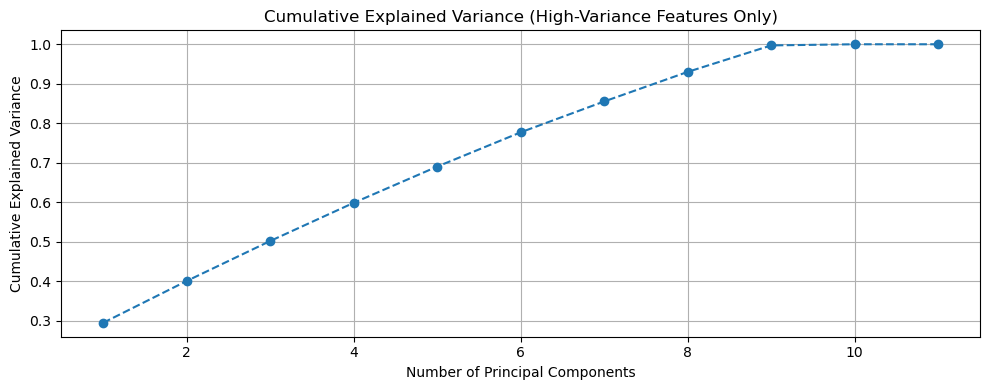

,PC1,PC2
Active_Months,0.591950,-0.092897
Total_Transactions,0.516173,0.012277
Num_Loan_Payment,0.338228,-0.425173
Num_Bill_Payment,0.311249,0.762823
Avg_Transactions_per_Month,0.244516,0.131481
Num_Purchase,0.242523,0.066935
Num_Investment,0.221706,-0.378094
Avg_Sentiment_Score,0.052924,-0.082402
Spend_StdDev,0.029287,-0.016084
Std_Satisfaction_Score,-0.018989,0.142926


In [60]:
# --- Select high-variance features ---
high_var_features_data3 = [
    "Active_Months",
    "Num_Bill_Payment",
    "Num_Loan_Payment",
    "Num_Investment",
    "Num_Purchase",
    "Avg_Transactions_per_Month",
    "Total_Transactions",
    "Spend_StdDev"
]

high_var_features_data1 = [
    "N_Feedback_Entries",
    "Avg_Sentiment_Score",
    "Std_Satisfaction_Score"
]

# --- Combine selected features ---
data_combined_high_var = pd.concat([
    data3_scaled_cleaned[high_var_features_data3],
    data1_scaled_cleaned[high_var_features_data1]
], axis=1)

# --- Handle missing values (impute with mean) ---
data_combined_high_var_cleaned = data_combined_high_var.fillna(data_combined_high_var.mean())

# --- Run PCA ---
pca = PCA()
pca_components = pca.fit_transform(data_combined_high_var_cleaned)

# --- Explained variance ---
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# --- Feature loadings ---
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=data_combined_high_var_cleaned.columns
)

# --- Plot cumulative variance ---
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title("Cumulative Explained Variance (High-Variance Features Only)")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Show most important features for PC1 and PC2 ---
loadings[['PC1', 'PC2']].sort_values(by='PC1', key=lambda x: abs(x), ascending=False)